In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import copy
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
from scipy.stats import fisher_exact
from scipy.stats import ttest_ind
from scipy.stats import percentileofscore
from scipy.spatial import KDTree
import math
# from sklearn.metrics import r2_score
%matplotlib inline
from matplotlib.lines import Line2D
import os
import warnings
import requests
import csv
import gzip
import re
# from brokenaxes import brokenaxes
from scipy.stats import mannwhitneyu
import matplotlib.cm as cm
# import ruptures as rpt
# from joypy import joyplot
from scipy.stats import linregress
# from Bio.PDB import PDBParser, MMCIFParser, NeighborSearch, Selection
# from Bio.PDB import MMCIFParser, Polypeptide
# from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from matplotlib.lines import Line2D
# from Bio import AlignIO
# from Bio import PDB
# from Bio.PDB import NeighborSearch
# from matplotlib_venn import venn3
from collections import Counter
# from Bio.PDB import PDBParser, Selection, NeighborSearch, Polypeptide
# from Bio.Data import IUPACData
from collections import Counter
# from joblib import Parallel, delayed
from tqdm import tqdm
import importlib, sys
from joypy import joyplot
import joypy.joyplot as _jp 

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.titlesize": 7,
    "svg.fonttype": "none", #keeps text editable
    "lines.linewidth": 0.5,     # lines (e.g., axvline) stroke width
    "axes.linewidth": 0.5,      # axis spines stroke width
    "patch.linewidth": 0.5,     # bars, histograms stroke width
    # "xtick.major.width": 0.5,
    # "ytick.major.width": 0.5,
    # "xtick.minor.width": 0.5,
    # "ytick.minor.width": 0.5
})

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 100)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
path = "Main2and3_outputs/"
os.makedirs(path, exist_ok=True)  

In [3]:
Replicate_scores = pd.read_csv('Supplementary_Table_2.tsv', sep='\t')
Replicate_scores = Replicate_scores.drop(columns = {'Mutation Type'})
Replicate_scores = Replicate_scores.rename(columns={'variant_category':'Mutation Type'})
Replicate_scores['Mutation Type'] = Replicate_scores['Mutation Type'].str.strip().replace('synonymous', 'synonymous wild type')
Replicate_scores['Mutation Type'] = Replicate_scores['Mutation Type'].str.strip().replace('3nt deletion', 'deletion')  
# # Replicate_scores['protein'] = Replicate_scores['library'].str.replace(r'(_nterm|_cterm)$', '', regex=True)
Replicate_scores


/tmp/27140413.1.shendure-login.q/ipykernel_1597488/3676062111.py:1: DtypeWarning: Columns (0: ensembl_protein, 1: chap_dep_classification, 2: buffered, 3: DN_EV, 4: ON_FUNCTION, 5: ON_PROCESS, 6: regulatory_PTM_note, 7: ligandable_cys, 8: inter_domain_partners, 9: kinase_motif, 10: nmd_zone) have mixed types. Specify dtype option on import or set low_memory=False.
  Replicate_scores = pd.read_csv('Sri_MAPK-LABEL-seq/output/annotated_combined.tsv', sep='\t')


,variant,Number of Barcodes,ratio_1,ratio_2,ratio_3,average ratio,score_1,score_2,score_3,variant_frequency,Wild Type Residue,Mutation,Position,hgvs_p,average_num_quant_bc,corrected_score_1,corrected_score_2,corrected_score_3,average score,intercept_0_std_adj_score_1,intercept_0_std_adj_score_2,intercept_0_std_adj_score_3,raw_std_adj_score_1,raw_std_adj_score_2,raw_std_adj_score_3,intercept_0_standard-adjusted score,library,assay,assay_treatment,classification_2.5pct,Mutation Type,uniprot_id,ensembl_protein,refseq_protein,mane_select,variant_class,count_data_delivery,protein,uniprot_accession,average_z_score,synon_wt_mean,synon_wt_std,average_z_score_from_syonWT,client_status_literature,Abund_chaperone_dependency,chap_dep_classification,Abund_chaperone_dependency_zscore_from_synon_WT,buffered,percent_buffered,percent_buffered_WT_norm,...,regulatory_PTM_note,regulatory_PTM,disease_associated_phosphosite,PMID39091798_Enrichment(ave)_FLshp2_CDsrc,PMID39091798_Enrichment(ave)_CDshp2_FLvsrc,ClinVar_Name,ClinicalSignificance,PhenotypeList,Origin,OriginSimple,ReviewStatus,NumberSubmitters,domain,hek_rna_tpm,hek_protein_conc_nm,hek_protein_copy_number,feature,active_site,interface_pdb_curated,interface_evidence,am_pathogenicity,alignment_pos,ligandable_cys,plddt,pdb_aa,inter_domain_contacts_all_atom,inter_domain_partners,pdb_aa_mismatch,hgvs_c,hgvs_g,clingen_allele_id,g_snvs_grch38,dn_threshold,interface_partners,n_interface_partners,at_hsp90_unfolded,at_hsp90_folded,at_cdc37,at_any_chaperone_contact,chaperone_contact_resolved,phylop_vert,jsd_conservation,kinase_motif,ddG_SPURS,in_gnomad,in_aou,min_nt_changes,gnomad_mappable,nmd_zone,genie_count
0,A11-,88.0,0.119781,0.124207,0.108533,0.122714,0.165388,0.162206,0.134652,0.000874,A,-,11,p.Ala11del,73.333333,0.165388,0.162206,0.134652,0.154082,0.055219,0.057294,0.049882,0.055219,0.057294,0.049882,0.054132,kras,abundance,LZTR1koCIAR,low,deletion,P01116-2,ENSP00000308495.3,NP_004976.2,False,original,260404 (April),kras,P01116,-2.111524,1.001442,0.07416,-11.426041,unknown,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,g_domain,19.650805,115.227262,69366.81148,G1 box; putative GDI interaction site,True,False,NaN,NaN,NaN,NaN,96.21,A,False,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0,False,False,False,False,False,7.916820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A11A,20.0,0.740325,0.727580,0.766027,0.747105,1.022204,0.950165,0.950376,0.000098,A,A,11,p.Ala11=,19.666667,1.022204,0.950165,0.950376,0.974248,0.341289,0.335617,0.352070,0.341289,0.335617,0.352070,0.342992,kras,abundance,LZTR1koCIAR,wt-like,synonymous wild type,P01116-2,ENSP00000308495.3,NP_004976.2,False,original,260404 (April),kras,P01116,0.332770,1.001442,0.07416,-0.366688,unknown,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,NaN,NaN,NM_004985.5(KRAS):c.33T>C (p.Ala11=),Likely benign,not specified,somatic,somatic,"criteria provided, single submitter",1.0,g_domain,19.650805,115.227262,69366.81148,G1 box; putative GDI interaction site,True,False,NaN,NaN,NaN,NaN,96.21,A,False,NaN,False,NM_004985.5:c.33T>A|NM_004985.5:c.33T>C|NM_004...,NC_000012.12:g.25245352A>T|NC_000012.12:g.2524...,PA2829563747,12:25245352:A:T|12:25245352:A:G|12:25245352:A:C,NaN,NaN,0,False,False,False,False,False,7.916820,NaN,NaN,0.000000,False,False,0.0,True,NaN,NaN
2,A11C,43.0,0.812878,0.736516,0.800486,0.791526,1.122380,0.961836,0.993128,0.000192,A,C,11,p.Ala11Cys,34.000000,1.122380,0.961836,0.993128,1.025781,0.374735,0.339739,0.367907,0.374735,0.339739,0.367907,0.360794,kras,abundance,LZTR1koCIAR,wt-like,missense,P01116-2,ENSP00000308495.3,NP_004976.2,False,original,260404 (April),kras,P01116,0.486350,1.001442,0.07416,0.328196,unknown,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,g_domain,19.650805,115.227262,69366.81148,G1 box; putative GDI interaction site,True,False,NaN,0.8834,NaN,NaN,96.21,A,False,NaN,False,NaN,NaN,PA3261985316,NaN,NaN,NaN,0,False,False,False,False,False,7.916820,NaN,NaN,0.478644,False,False,2.0,True

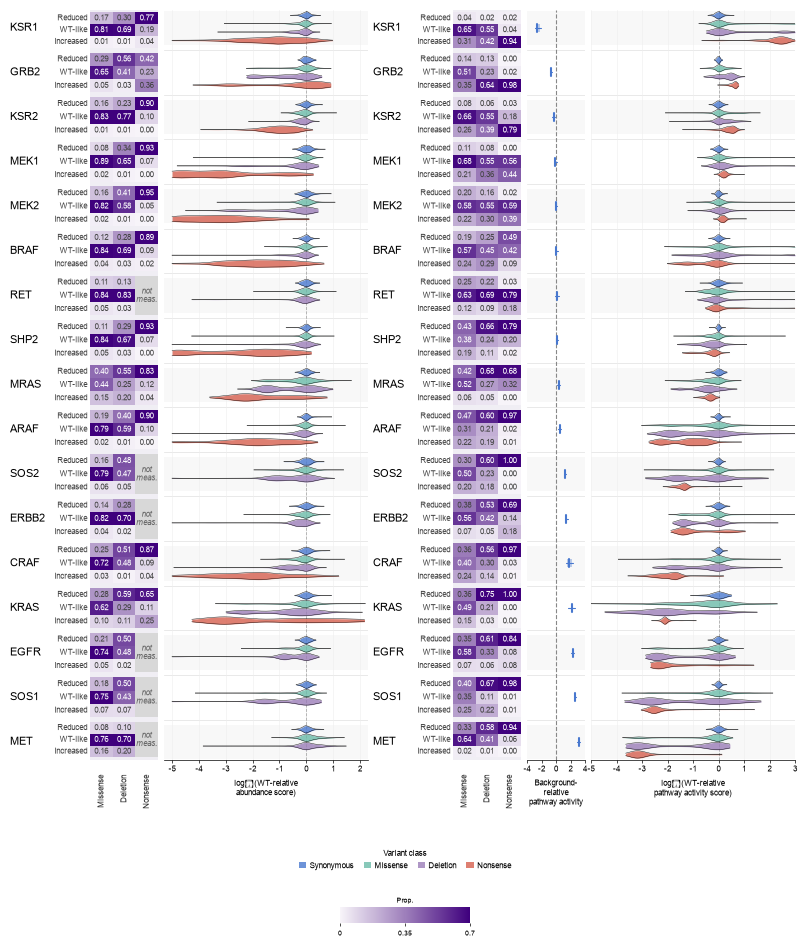

In [6]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# `path` and `Replicate_scores` are assumed to already exist in your
# notebook/session, exactly as in your original 2a/2c scripts.

mpl.rcParams['font.family']     = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['pdf.fonttype']    = 42
mpl.rcParams['ps.fonttype']     = 42
mpl.rcParams['svg.fonttype']    = 'none'

# ── Shared constants ───────────────────────────────────────────────────────
STD_COL     = 'intercept_0_standard-adjusted score'
AVG_COL     = 'average score'
FONT_SM     = 6
FONT_MD     = 6    # x-axis title labels
HEAT_FONT   = 5     # colorbar ticks/title
HEAT_CELL_FONT  = 5.5   # numbers + "not meas." text inside heatmap cells
HEAT_LABEL_FONT = 6 # "Reduced/WT-like/Increased" + "Missense/Deletion/Nonsense" labels
KDE_PTS     = 300
CLIP_LO_REL = 2**-5

mut_order  = ['synonymous wild type', 'missense', 'deletion', 'nonsense']
mut_labels = ['Synonymous', 'Missense', 'Deletion', 'Nonsense']
mut_colors = ['#4878CF', '#6ABBA8', '#9B7DB8', '#D65F4E']
n_muts     = len(mut_order)

heat_mut_order    = ['missense', 'deletion', 'nonsense']
heat_mut_labels   = ['Missense', 'Deletion', 'Nonsense']
heat_classes      = ['low', 'wt-like', 'high']
heat_class_labels = ['Reduced', 'WT-like', 'Increased']
n_heat_cols       = len(heat_mut_order)

cmap_heat = mpl.colors.LinearSegmentedColormap.from_list(
    'heat', ['#F7F4F9', '#9E7FBB', '#3F007D']
)
norm_heat = mpl.colors.Normalize(vmin=0, vmax=0.7)

SPECIAL_LAST    = ['EGFR', 'SOS1', 'SOS2', 'ERBB2', 'RET', 'MET']
_special_lower  = {p.lower() for p in SPECIAL_LAST}
_special_order  = {p.lower(): i for i, p in enumerate(SPECIAL_LAST)}

WITHIN_GAP    = 0.75
BETWEEN_GAP   = 1.0
group_step    = n_muts * WITHIN_GAP + BETWEEN_GAP
VIOLIN_HALF_H = WITHIN_GAP * 0.44
HEAT_PAD      = 0.22

def group_y(pi, mi):
    return pi * group_step + mi * WITHIN_GAP

def heat_data_for(assay):
    heat_data = {}
    for mut in heat_mut_order:
        sub = Replicate_scores[
            (Replicate_scores['assay'] == assay) &
            (Replicate_scores['Mutation Type'] == mut) &
            (Replicate_scores['assay_treatment'].isin(['DMSO', 'No_treatment'])) &
            (Replicate_scores['classification_2.5pct'].isin(heat_classes))
        ]
        counts = sub.groupby(['protein', 'classification_2.5pct']).size().unstack(fill_value=0)
        for cls in heat_classes:
            if cls not in counts.columns:
                counts[cls] = 0
        heat_data[mut] = counts[heat_classes].div(counts[heat_classes].sum(axis=1), axis=0)
    return heat_data

def y_layout(n_proteins):
    y_min = group_y(0, 0) - WITHIN_GAP * 0.65
    y_max = group_y(n_proteins - 1, n_muts - 1) + WITHIN_GAP * 0.65
    sep_ys = [group_y(pi, n_muts - 1) + (WITHIN_GAP + BETWEEN_GAP) / 2
              for pi in range(n_proteins - 1)]
    heat_bottom = [y_min] + sep_ys
    heat_top    = sep_ys + [y_max]
    return y_min, y_max, sep_ys, heat_bottom, heat_top

# ══════════════════════════════ ABUNDANCE DATA ══════════════════════════════
ASSAY_AB = 'abundance'
base_mask_ab = (
    (Replicate_scores['assay'] == ASSAY_AB) &
    (Replicate_scores['assay_treatment'].isin(['DMSO', 'No_treatment'])) &
    (Replicate_scores['Mutation Type'].isin(mut_order))
)
box_base_ab  = Replicate_scores[base_mask_ab & Replicate_scores[STD_COL].notna()].copy()
viol_base_ab = Replicate_scores[base_mask_ab & Replicate_scores[AVG_COL].notna()].copy()

wt_avg_median_ab = (
    viol_base_ab[viol_base_ab['Mutation Type'] == 'synonymous wild type']
    .groupby('protein')[AVG_COL].median()
)
viol_base_ab['_wt_rel']   = viol_base_ab[AVG_COL] / viol_base_ab['protein'].map(wt_avg_median_ab)
viol_base_ab['_log2_rel'] = np.log2(viol_base_ab['_wt_rel'].clip(lower=CLIP_LO_REL))

# protein order still driven by the standardized score even though the box
# panel itself is no longer drawn for abundance
wt_std_median_ab = (
    box_base_ab[box_base_ab['Mutation Type'] == 'synonymous wild type']
    .groupby('protein')[STD_COL].median()
)
_sorted_all_ab        = wt_std_median_ab.sort_values(ascending=False).index.tolist()
non_special_ab        = [p for p in _sorted_all_ab if p.lower() not in _special_lower]
special_found_ab      = [p for p in _sorted_all_ab if p.lower() in _special_lower]
special_reordered_ab  = sorted(special_found_ab, key=lambda p: _special_order.get(p.lower(), 999))
order_ab      = (non_special_ab + special_reordered_ab)[::-1]
n_proteins_ab = len(order_ab)

_viol_log2_all_ab = viol_base_ab.loc[
    viol_base_ab['protein'].isin(order_ab) & viol_base_ab['Mutation Type'].isin(mut_order),
    '_log2_rel'
].dropna()
XMIN_AB = np.floor(_viol_log2_all_ab.min()) - 0.3
XMAX_AB = 2.3

heat_data_ab = heat_data_for(ASSAY_AB)
y_min_ab, y_max_ab, sep_ys_ab, heat_bottom_ab, heat_top_ab = y_layout(n_proteins_ab)

# ══════════════════════════════ ACTIVITY DATA ═══════════════════════════════
ASSAY_ACT      = 'activity'
BOX_NORM_FLOOR = 2**-6
XMIN_L2, XMAX_L2 = -5, 3

base_mask_act = (
    (Replicate_scores['assay'] == ASSAY_ACT) &
    (Replicate_scores['assay_treatment'].isin(['DMSO', 'No_treatment'])) &
    (Replicate_scores['Mutation Type'].isin(mut_order))
)
box_base_act  = Replicate_scores[base_mask_act & Replicate_scores[STD_COL].notna()].copy()
viol_base_act = Replicate_scores[base_mask_act & Replicate_scores[AVG_COL].notna()].copy()

ev_mask_act = (
    (Replicate_scores['assay'] == ASSAY_ACT) &
    (Replicate_scores['assay_treatment'].isin(['DMSO', 'No_treatment'])) &
    (Replicate_scores['variant'] == 'empty_vector_std') &
    (Replicate_scores[STD_COL].notna())
)
ev_std_median_act = Replicate_scores[ev_mask_act].groupby('protein')[STD_COL].median()

wt_avg_median_act = (
    viol_base_act[viol_base_act['Mutation Type'] == 'synonymous wild type']
    .groupby('protein')[AVG_COL].median()
)
viol_base_act['_wt_rel']   = viol_base_act[AVG_COL] / viol_base_act['protein'].map(wt_avg_median_act)
viol_base_act['_log2_rel'] = np.log2(viol_base_act['_wt_rel'].clip(lower=CLIP_LO_REL))

wt_std_median_act = (
    box_base_act[box_base_act['Mutation Type'] == 'synonymous wild type']
    .groupby('protein')[STD_COL].median()
)

bg_rel_score_act  = (wt_std_median_act / ev_std_median_act).replace([np.inf, -np.inf], np.nan).dropna()
bg_rel_sorted_act = bg_rel_score_act.sort_values(ascending=False)
no_ev_act = [p for p in wt_std_median_act.sort_values(ascending=False).index
             if p not in bg_rel_sorted_act.index]
order_act      = (bg_rel_sorted_act.index.tolist() + no_ev_act)[::-1]
n_proteins_act = len(order_act)

# ── Re-order abundance to match the activity ordering ────────────────────────
# Activity's own order (order_act) is left untouched. Proteins abundance and
# activity have in common are put in abundance in the SAME sequence as
# activity. Any protein that only exists in the abundance panel (e.g. the
# receptor-tyrosine-kinase "SPECIAL_LAST" proteins with no activity readout)
# keeps its old abundance-specific sort and is placed as a block ABOVE the
# activity-matched proteins. Flip the block order below if you'd rather have
# those abundance-only proteins at the bottom instead.
_act_order_set   = set(order_act)
_common_ab       = [p for p in order_act if p in wt_std_median_ab.index]
_abundance_only  = [p for p in order_ab if p not in _act_order_set]
order_ab         = _abundance_only + _common_ab
n_proteins_ab    = len(order_ab)

heat_data_act = heat_data_for(ASSAY_ACT)
y_min_act, y_max_act, sep_ys_act, heat_bottom_act, heat_top_act = y_layout(n_proteins_act)

syn_wt_box_act    = box_base_act[box_base_act['Mutation Type'] == 'synonymous wild type']
_all_log2_nrm_act = []
for protein in order_act:
    if protein not in ev_std_median_act.index:
        continue
    ev_med = ev_std_median_act[protein]
    if ev_med <= 0:
        continue
    vals = syn_wt_box_act.loc[syn_wt_box_act['protein'] == protein, STD_COL].dropna().values
    if len(vals) == 0:
        continue
    _all_log2_nrm_act.extend(np.log2(np.clip(vals / ev_med, BOX_NORM_FLOOR, None)).tolist())

BOX_XMIN_ACT = np.floor(np.percentile(_all_log2_nrm_act, 1) - 0.3) if _all_log2_nrm_act else -3
BOX_XMAX_ACT = np.ceil( np.percentile(_all_log2_nrm_act, 99) + 0.3) if _all_log2_nrm_act else 7

# ══════════════════════════════ FIGURE LAYOUT ═══════════════════════════════
# 8" x 8" total for BOTH panels together. Heatmap / box / violin column
# widths (inches) are identical between the abundance group and the activity
# group -- abundance simply omits the box column.
# 8" wide. Height: the plot region itself (heatmaps/box/violin + their x-axis
# labels) is fixed at 7.5in; the shared legend/colorbar strip is added BELOW
# that and does not count toward the 7.5in.
FIG_W        = 8.0
PLOT_H       = 8.5    # top margin + axes + x-axis label text ONLY
TOP_MARGIN   = 0.35
XLABEL_SPACE = 0.65   # room for x-axis tick labels + multi-line x-axis title
LEGEND_H     = 1.30   # legend + colorbar strip, added on top of PLOT_H

FIG_H = PLOT_H + LEGEND_H

LEFT_MARGIN  = 0.85   # protein names + row labels, left of the abundance heatmap
HEAT_W       = 0.68   # <- identical in both groups
INTRA_GAP    = 0.06   # gap between heat/box/violin within one group
VIOL_W       = 2.04   # <- identical in both groups (widened from 1.84)
MID_GAP      = 0.85   # protein names + row labels, left of the activity heatmap
BOX_W        = 0.58   # activity-only box column
RIGHT_MARGIN = 0.10   # small buffer for the last x-tick label

def frac_x(inches):
    return inches / FIG_W

def frac_y(inches):
    return inches / FIG_H

axes_bottom_in = LEGEND_H + XLABEL_SPACE   # axes start above the legend strip
axes_top_in    = FIG_H - TOP_MARGIN
axes_bottom    = axes_bottom_in / FIG_H
axes_top       = axes_top_in / FIG_H
axes_h         = axes_top - axes_bottom

x = LEFT_MARGIN
x_heat_ab = x;  x += HEAT_W + INTRA_GAP
x_viol_ab = x;  x += VIOL_W + MID_GAP
x_heat_act = x; x += HEAT_W + INTRA_GAP
x_box_act = x;  x += BOX_W + INTRA_GAP
x_viol_act = x; x += VIOL_W
x_end = x + RIGHT_MARGIN
assert abs(x_end - FIG_W) < 0.05, f'layout does not fit 8in width: {x_end:.3f}'

# Protein-name x positions: left of each group's heatmap (near the outer
# edge of that group's margin, further out than the small class row labels).
protein_label_x_ab_in  = 0.05
protein_label_x_act_in = x_viol_ab + VIOL_W + 0.05

fig = plt.figure(figsize=(FIG_W, FIG_H))

def add_ax(x0, w):
    return fig.add_axes([frac_x(x0), axes_bottom, frac_x(w), axes_h])

ax_heat_ab  = add_ax(x_heat_ab, HEAT_W)
ax_viol_ab  = add_ax(x_viol_ab, VIOL_W)
ax_heat_act = add_ax(x_heat_act, HEAT_W)
ax_box_act  = add_ax(x_box_act, BOX_W)
ax_viol_act = add_ax(x_viol_act, VIOL_W)

# ══════════════════════════════ DRAW HEATMAPS ═══════════════════════════════
def draw_heatmap(ax, heat_data, order, heat_bottom, heat_top, n_proteins, special_lower=None):
    for ci_mut, mut in enumerate(heat_mut_order):
        for pi, protein in enumerate(order):
            gy_start = heat_bottom[pi] + HEAT_PAD
            blk_h    = heat_top[pi] - heat_bottom[pi] - 2 * HEAT_PAD
            ch       = blk_h / len(heat_classes)

            if special_lower and mut == 'nonsense' and protein.lower() in special_lower:
                ax.add_patch(mpl.patches.Rectangle(
                    (ci_mut, gy_start), 1, blk_h,
                    facecolor='#D8D8D8', edgecolor='none', linewidth=0, zorder=2,
                ))
                ax.text(ci_mut + 0.5, gy_start + blk_h / 2, 'not\nmeas.',
                        ha='center', va='center', fontsize=HEAT_CELL_FONT, zorder=3,
                        color='#666666', style='italic')
                continue

            for ci_cls, cls in enumerate(heat_classes):
                df  = heat_data[mut]
                val = df.loc[protein, cls] if protein in df.index else 0.0
                ax.add_patch(mpl.patches.Rectangle(
                    (ci_mut, gy_start + ci_cls * ch), 1, ch,
                    facecolor=cmap_heat(norm_heat(val)),
                    edgecolor='none', linewidth=0, zorder=2,
                ))
                ax.text(ci_mut + 0.5, gy_start + ci_cls * ch + ch / 2, f'{val:.2f}',
                        ha='center', va='center', fontsize=HEAT_CELL_FONT, zorder=3,
                        color='white' if val > 0.38 else '#444444')

    _hbtrans = mpl.transforms.blended_transform_factory(ax.transData, ax.transAxes)
    for ci_mut, lbl in enumerate(heat_mut_labels):
        ax.text(ci_mut + 0.5, -0.02, lbl, ha='center', va='top', rotation=90,
                fontsize=HEAT_LABEL_FONT, color='#333333', transform=_hbtrans, clip_on=False)

    _hltrans = mpl.transforms.blended_transform_factory(ax.transAxes, ax.transData)
    for pi in range(n_proteins):
        gy_start = heat_bottom[pi] + HEAT_PAD
        blk_h    = heat_top[pi] - heat_bottom[pi] - 2 * HEAT_PAD
        ch       = blk_h / len(heat_classes)
        for ci_cls, lbl in enumerate(heat_class_labels):
            ax.text(-0.04, gy_start + ci_cls * ch + ch / 2, lbl,
                    ha='right', va='center', fontsize=HEAT_LABEL_FONT, color='#444444',
                    transform=_hltrans, clip_on=False)

    ax.set_xlim(0, n_heat_cols)
    ax.set_ylim(heat_bottom[0], heat_top[-1])
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor('#F0EEF4')
    for spine in ax.spines.values():
        spine.set_visible(False)

draw_heatmap(ax_heat_ab, heat_data_ab, order_ab, heat_bottom_ab, heat_top_ab,
             n_proteins_ab, special_lower=_special_lower)
draw_heatmap(ax_heat_act, heat_data_act, order_act, heat_bottom_act, heat_top_act,
             n_proteins_act, special_lower=None)

# ── Protein-name labels, to the LEFT of each group's heatmap ─────────────────
def draw_protein_labels(ax, order, x_in):
    # x in figure-fraction, y in this axis's data coordinates -> independent
    # of axis width, so the label sits at a fixed physical position.
    trans = mpl.transforms.blended_transform_factory(fig.transFigure, ax.transData)
    for pi, protein in enumerate(order):
        yc = group_y(pi, (n_muts - 1) / 2)
        ax.text(frac_x(x_in), yc, protein.upper(), ha='left', va='center',
                fontsize=8, transform=trans, clip_on=False)

draw_protein_labels(ax_heat_ab, order_ab, protein_label_x_ab_in)
draw_protein_labels(ax_heat_act, order_act, protein_label_x_act_in)

# ══════════════════════════════ ACTIVITY BOX PLOT (abundance has none) ═════
BOX_COLOR  = '#4878CF'
BOX_HALF_H = WITHIN_GAP * 0.48

for pi, protein in enumerate(order_act):
    yc = group_y(pi, (n_muts - 1) / 2)
    if protein not in ev_std_median_act.index:
        continue
    ev_med = ev_std_median_act[protein]
    if ev_med <= 0:
        continue
    vals = syn_wt_box_act.loc[syn_wt_box_act['protein'] == protein, STD_COL].dropna().values
    if len(vals) == 0:
        continue

    log2_vals = np.log2(np.clip(vals / ev_med, BOX_NORM_FLOOR, None))
    q05, q25, med, q75, q95 = np.percentile(log2_vals, [5, 25, 50, 75, 95])
    q05, q25, med, q75, q95 = (np.clip(v, BOX_XMIN_ACT, BOX_XMAX_ACT)
                                for v in (q05, q25, med, q75, q95))

    if pi % 2 == 0:
        ax_box_act.axhspan(
            group_y(pi, 0) - WITHIN_GAP * 0.55,
            group_y(pi, n_muts - 1) + WITHIN_GAP * 0.55,
            color='#F8F8F8', zorder=0, linewidth=0,
        )

    ax_box_act.plot([q05, q95], [yc, yc], color=BOX_COLOR, linewidth=0.8,
                     solid_capstyle='round', zorder=2)
    ax_box_act.add_patch(mpl.patches.Rectangle(
        (q25, yc - BOX_HALF_H), q75 - q25, BOX_HALF_H * 2,
        facecolor=BOX_COLOR, alpha=0.35, linewidth=0, zorder=3,
    ))
    ax_box_act.plot([med, med], [yc - BOX_HALF_H, yc + BOX_HALF_H],
                     color=BOX_COLOR, linewidth=1.5, solid_capstyle='round', zorder=4)

ax_box_act.axvline(0, color='#888888', linestyle='--', linewidth=0.8, zorder=1)
for sy in sep_ys_act:
    ax_box_act.axhline(sy, color='#E0E0E0', linewidth=0.5, zorder=0)

ax_box_act.set_xlim(BOX_XMIN_ACT, BOX_XMAX_ACT)
ax_box_act.set_ylim(y_min_act, y_max_act)
ax_box_act.invert_yaxis()
ax_box_act.set_yticks([])
ax_box_act.xaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
ax_box_act.xaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda x, _: f'{int(x)}' if x == int(x) else ''))
ax_box_act.set_xlabel('Background-\nrelative\npathway activity', fontsize=FONT_MD, labelpad=4)
ax_box_act.tick_params(axis='x', labelsize=FONT_SM, length=2, width=0.5, pad=2)
ax_box_act.spines[['left', 'right', 'top']].set_visible(False)
ax_box_act.spines['bottom'].set_linewidth(0.5)

# ══════════════════════════════ VIOLINS ═════════════════════════════════════
def draw_violin(ax, viol_base, order, y_min, y_max, xmin, xmax, sep_ys, xlabel_text):
    for pi, protein in enumerate(order):
        if pi % 2 == 0:
            ax.axhspan(
                group_y(pi, 0) - WITHIN_GAP * 0.55,
                group_y(pi, n_muts - 1) + WITHIN_GAP * 0.55,
                color='#F8F8F8', zorder=0, linewidth=0,
            )
        for mi, (mut, color) in enumerate(zip(mut_order, mut_colors)):
            rel_vals = viol_base.loc[
                (viol_base['protein'] == protein) & (viol_base['Mutation Type'] == mut),
                '_log2_rel'
            ].dropna().values
            vals_clamped = np.clip(rel_vals, xmin, xmax)
            yc = group_y(pi, mi)

            if len(vals_clamped) < 5:
                if len(vals_clamped):
                    ax.plot(np.median(vals_clamped), yc, marker='|', color=color,
                             markersize=5, zorder=4)
                continue

            kde   = gaussian_kde(vals_clamped, bw_method='scott')
            x_lo  = max(vals_clamped.min(), xmin)
            x_hi  = min(vals_clamped.max(), xmax)
            x_pts = np.linspace(x_lo, x_hi, KDE_PTS)
            dens  = kde(x_pts) / kde(x_pts).max()
            hh    = dens * VIOLIN_HALF_H

            ax.fill_between(x_pts, yc - hh, yc + hh, color=color, alpha=0.80,
                             linewidth=0, zorder=2)
            ax.plot(x_pts, yc - hh, color='black', linewidth=0.3, zorder=3)
            ax.plot(x_pts, yc + hh, color='black', linewidth=0.3, zorder=3)

    ax.set_ylim(y_min, y_max)
    ax.set_xlim(xmin, xmax)
    ax.invert_yaxis()
    ax.autoscale(enable=False)
    ax.axvline(0, color='#999999', linestyle='--', linewidth=0.6, alpha=0.8, zorder=1)
    for sy in sep_ys:
        ax.axhline(sy, color='#E0E0E0', linewidth=0.5, zorder=0)
    for xt in range(int(np.floor(xmin)), int(np.ceil(xmax)) + 1):
        ax.axvline(xt, color='#EEEEEE', linewidth=0.4, zorder=0)

    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f'{int(x)}' if x == int(x) else ''))
    ax.set_yticks([])
    ax.set_xlabel(xlabel_text, fontsize=FONT_MD, labelpad=4)
    ax.tick_params(axis='x', labelsize=FONT_SM, length=2, width=0.5, pad=2)
    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)

draw_violin(ax_viol_ab, viol_base_ab, order_ab, y_min_ab, y_max_ab, XMIN_AB, XMAX_AB,
            sep_ys_ab, 'log₂(WT-relative\nabundance score)')
draw_violin(ax_viol_act, viol_base_act, order_act, y_min_act, y_max_act, XMIN_L2, XMAX_L2,
            sep_ys_act, 'log₂(WT-relative\npathway activity score)')

# ══════════════════════════════ SHARED LEGEND (below both plots) ═══════════
LEGEND_Y_IN = 0.95
CBAR_Y_IN   = 0.32
CBAR_W_IN, CBAR_H_IN = 1.3, 0.16

legend_handles = [
    mpl.patches.Patch(facecolor=c, edgecolor='none', alpha=0.80, label=l)
    for c, l in zip(mut_colors, mut_labels)
]
fig.legend(
    handles=legend_handles, loc='center', bbox_to_anchor=(0.5, frac_y(LEGEND_Y_IN)),
    fontsize=FONT_SM, frameon=False, ncol=4,
    handlelength=0.9, handleheight=0.75, handletextpad=0.4, columnspacing=1.2,
    borderpad=0, title='Variant class', title_fontsize=FONT_SM,
)

cbar_x_in = FIG_W / 2 - CBAR_W_IN / 2
cbar_ax = fig.add_axes([frac_x(cbar_x_in), frac_y(CBAR_Y_IN),
                         frac_x(CBAR_W_IN), frac_y(CBAR_H_IN)])
sm = plt.cm.ScalarMappable(cmap=cmap_heat, norm=norm_heat)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks([0, 0.35, 0.7])
cbar.set_ticklabels(['0', '0.35', '0.7'])
cbar.ax.tick_params(labelsize=HEAT_FONT, length=2, width=0.5)
cbar.outline.set_visible(False)
cbar.ax.set_title('Prop.', fontsize=HEAT_FONT, pad=3)

# NOTE: no bbox_inches='tight' here on purpose -- that would crop the canvas
# and the saved file would no longer be exactly 8in x 8in.
plt.savefig(path + '2ac_combined.svg')

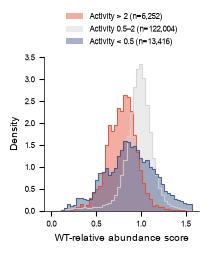

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Overlaid histograms: abundance score by activity score bin
# Activity bins: >2 (high), 0.5–2 (intermediate), <0.5 (low)
# Filtered to assay_treatment == DMSO or No_treatment
# ══════════════════════════════════════════════════════════════════════════════

treatments = ['DMSO', 'No_treatment']

# Abundance scores (average, not std-adjusted), one row per variant
abund_df2 = (
    Replicate_scores[
        (Replicate_scores['assay'] == 'abundance') &
        (Replicate_scores['Mutation Type'] == 'missense') &
        (Replicate_scores['assay_treatment'].isin(treatments))
    ][['library', 'variant', 'average score']]
    .drop_duplicates(subset=['library', 'variant'])
    .rename(columns={'average score': 'abund_score'})
)

# Activity scores (average, not std-adjusted), one row per variant
act_df2 = (
    Replicate_scores[
        (Replicate_scores['assay'] == 'activity') &
        (Replicate_scores['Mutation Type'] == 'missense') &
        (Replicate_scores['assay_treatment'].isin(treatments))
    ][['library', 'variant', 'average score']]
    .drop_duplicates(subset=['library', 'variant'])
    .rename(columns={'average score': 'act_score'})
)

# Merge and drop missing
merged2 = abund_df2.merge(act_df2, on=['library', 'variant'], how='inner')
merged2 = merged2.dropna(subset=['abund_score', 'act_score'])

# Bin by activity score
def activity_bin(score):
    if score > 2:
        return 'high'
    elif score < 0.5:
        return 'low'
    else:
        return 'intermediate'

merged2['act_bin'] = merged2['act_score'].apply(activity_bin)

# ── Plot ──────────────────────────────────────────────────────────────────────
bin_styles = {
    'high':         {'color': '#E64B35', 'label': 'Activity > 2'},
    'intermediate': {'color': '#D3D3D3', 'label': 'Activity 0.5–2'},
    'low':          {'color': '#3C5488', 'label': 'Activity < 0.5'},
}

bins = np.arange(0, 1.6, 0.035)

# NOTE: 'Helvetica' isn't installed on this system (only Arial/DejaVu Sans
# are) -- setting it as the *only* sans-serif candidate here (with no
# fallback) made matplotlib's font_manager log a "findfont ... not found"
# warning for every single text object drawn in every cell run afterward,
# since this rcParam persists for the rest of the kernel session. Using
# 'Arial' (as the other panels in this notebook already do) renders
# identically on this system and avoids the warning entirely.
mpl.rcParams['font.family']     = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['svg.fonttype']    = 'none'
mpl.rcParams['font.size']       = 7

fig, ax = plt.subplots(figsize=(2, 2))
fig.patch.set_alpha(0)   # transparent figure background
ax.patch.set_alpha(0)    # transparent axes background

for grp, style in bin_styles.items():
    data = merged2.loc[merged2['act_bin'] == grp, 'abund_score']
    if data.empty:
        continue
    ax.hist(
        data,
        bins=bins,
        density=True,
        histtype='stepfilled',
        alpha=0.45,
        color=style['color'],
        edgecolor='none',
        label=f"{style['label']} (n={len(data):,})",
    )
    ax.hist(
        data,
        bins=bins,
        density=True,
        histtype='step',
        alpha=0.85,
        color=style['color'],
        linewidth=0.8,
    )

ax.set_xlabel('WT-relative abundance score', fontsize=7)
ax.set_ylabel('Density', fontsize=7)
ax.tick_params(labelsize=6)
# Legend moved above the axes (instead of to the right) -- keeps the saved
# figure narrower, which leaves more room for panel 2g in the compilation.
ax.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=1, fontsize=6)
sns.despine(ax=ax)

plt.savefig(path+'2e.svg', bbox_inches='tight')


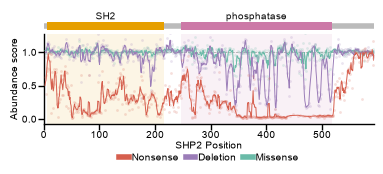

In [11]:
# ── SHP2 abundance/domain plot (saved as "2b") — domain track + score track, 3.9in x 1.75in, legend at bottom (one row) ──
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.transforms import blended_transform_factory

mpl.rcParams['font.family']     = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

PROT     = 'shp2'
PROT_LEN = 593

WINDOW      = 3
LINE_WIDTH  = 0.7
DOT_SIZE    = 4
BACKBONE_LW = 4
X_PAD       = 10
LABEL_FS    = 7

# Colors matched to the combined abundance/activity figure's variant-class
# palette (mut_colors = ['#4878CF', '#6ABBA8', '#9B7DB8', '#D65F4E'] for
# synonymous / missense / deletion / nonsense). This plot doesn't draw a
# synonymous track, but if you add one later it should be '#4878CF'.
COLOR_SYNONYMOUS = '#4878CF'   # not currently plotted; included for reference
COLOR_MISSENSE   = '#6ABBA8'
COLOR_DELETION   = '#9B7DB8'
COLOR_NONSENSE   = '#D65F4E'

DOMAIN_COLORS = {
    'SH2':         '#E69F00',
    'phosphatase': '#CC79A7',
    'other':       '#CCCCCC',
}
DOMAIN_COL_RENAME = {
    'sh2': 'SH2', 'sh2_1': 'SH2', 'sh2_2': 'SH2',
    'phosphatase': 'phosphatase',
}

prot_scores = Replicate_scores[Replicate_scores['protein'] == PROT].copy()
prot_scores['Position'] = pd.to_numeric(prot_scores['Position'], errors='coerce')

def _position_scores(mut_type):
    sub = prot_scores[
        (prot_scores['Mutation Type'] == mut_type) &
        (prot_scores['assay'] == 'abundance') &
        prot_scores['Position'].notna()
    ].copy()
    sub['Position'] = sub['Position'].astype(int)
    return sub.groupby('Position')['average score'].mean().reset_index().sort_values('Position')

p_ns  = _position_scores('nonsense')
p_del = _position_scores('deletion')
p_mis = _position_scores('missense')

def get_domains_from_scores(gap_threshold=30):
    sub = prot_scores[
        prot_scores['domain'].notna() & (prot_scores['domain'] != 'none')
    ].dropna(subset=['Position']).copy()
    sub['Position'] = sub['Position'].astype(int)
    if len(sub) == 0:
        return pd.DataFrame(columns=['From', 'To', 'domain_label'])

    pos_dom = (
        sub.groupby('Position')['domain']
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={'domain': 'domain_label'})
        .sort_values('Position')
    )
    pos_dom['domain_label'] = pos_dom['domain_label'].map(lambda x: DOMAIN_COL_RENAME.get(x, x))

    rows = []
    pos_arr = pos_dom['Position'].values
    dom_arr = pos_dom['domain_label'].values
    start, current_dom, prev_pos = int(pos_arr[0]), dom_arr[0], int(pos_arr[0])
    for i in range(1, len(pos_arr)):
        pos, dom = int(pos_arr[i]), dom_arr[i]
        if dom != current_dom or pos - prev_pos > gap_threshold:
            rows.append({'From': start, 'To': prev_pos, 'domain_label': current_dom})
            start, current_dom = pos, dom
        prev_pos = pos
    rows.append({'From': start, 'To': prev_pos, 'domain_label': current_dom})
    return pd.DataFrame(rows)

def get_uncovered_regions(pos_list, x_lo, x_hi, gap_threshold=20):
    if not len(pos_list):
        return []
    all_pos = np.array(sorted(set(int(p) for p in pos_list)))
    all_pos = all_pos[(all_pos >= x_lo) & (all_pos <= x_hi)]
    if not len(all_pos):
        return []
    return [(int(all_pos[i]), int(all_pos[i + 1]))
            for i in range(len(all_pos) - 1)
            if all_pos[i + 1] - all_pos[i] > gap_threshold]

doms = get_domains_from_scores()
all_scored = list(p_ns['Position']) + list(p_del['Position']) + list(p_mis['Position'])
x_lo = max(0, min(all_scored) - X_PAD) if all_scored else 0
x_hi = min(PROT_LEN, max(all_scored) + X_PAD) if all_scored else PROT_LEN
uncovered = get_uncovered_regions(all_scored, x_lo, x_hi)
dw = (x_hi - x_lo) * 0.013

FIG_W         = 4.5
FIG_H         = 1.45
LEFT_MARGIN   = 1.00
RIGHT_MARGIN  = 0.20
TOP_PAD       = 0.19
DOM_H         = 0.20
DOM_SCORE_GAP = 0.04
SCORE_H       = 0.90
XLABEL_H      = 0.32
LEGEND_H      = 0.10

COL_W = FIG_W - LEFT_MARGIN - RIGHT_MARGIN
PLOT_CENTER_X = (LEFT_MARGIN + COL_W / 2) / FIG_W

DOM_BAR_H   = 0.65
DOM_GAP_H   = DOM_BAR_H + 0.03
DOM_LABEL_Y = DOM_BAR_H / 2 + 0.035

_HASH_H     = 0.07
_bar_ctr_ax = 0.35 / 1.65
dom_hash_y  = [_bar_ctr_ax - (_HASH_H / DOM_H) / 2,  _bar_ctr_ax + (_HASH_H / DOM_H) / 2]
sc_hash_y   = [-(_HASH_H / SCORE_H) / 2, (_HASH_H / SCORE_H) / 2]

fig_shp2 = plt.figure(figsize=(FIG_W, FIG_H))
score_bottom_in = XLABEL_H + LEGEND_H
dom_bottom_in   = score_bottom_in + SCORE_H + DOM_SCORE_GAP

ax_dom = fig_shp2.add_axes([LEFT_MARGIN / FIG_W, dom_bottom_in   / FIG_H, COL_W / FIG_W, DOM_H   / FIG_H])
ax_sc  = fig_shp2.add_axes([LEFT_MARGIN / FIG_W, score_bottom_in / FIG_H, COL_W / FIG_W, SCORE_H / FIG_H])

ax_dom.set_xlim(x_lo, x_hi)
ax_dom.set_ylim(-0.35, 1.30)
ax_dom.axis('off')
ax_dom.plot([x_lo, x_hi], [0, 0], color='#BBBBBB', linewidth=BACKBONE_LW,
            solid_capstyle='butt', zorder=1)

for _, drow in doms.iterrows():
    dlbl = drow['domain_label']
    col  = DOMAIN_COLORS.get(dlbl, DOMAIN_COLORS['other'])
    w    = drow['To'] - drow['From']
    ax_dom.barh(0, w, left=drow['From'], color=col, edgecolor='none',
                linewidth=0, height=DOM_BAR_H, zorder=2)
    mid = drow['From'] + w / 2
    if x_lo <= mid <= x_hi and w / (x_hi - x_lo) > 0.04:
        ax_dom.text(mid, DOM_LABEL_Y, dlbl, ha='center', va='bottom',
                    fontsize=LABEL_FS, color='#111111', clip_on=True)

for uc_s, uc_e in uncovered:
    ax_dom.barh(0, uc_e - uc_s, left=uc_s, facecolor='white', edgecolor='#888888',
                linewidth=0, height=DOM_GAP_H, zorder=4, hatch='////', alpha=0.55)

trans_dom = blended_transform_factory(ax_dom.transData, ax_dom.transAxes)
for edge, cond in [(x_lo, x_lo > 0), (x_hi, x_hi < PROT_LEN)]:
    if cond:
        ax_dom.plot([edge - dw, edge + dw], dom_hash_y, transform=trans_dom,
                    color='#333333', lw=2.0, clip_on=False, zorder=11,
                    solid_capstyle='round')

for _, drow in doms.iterrows():
    col_d = DOMAIN_COLORS.get(drow['domain_label'], DOMAIN_COLORS['other'])
    ax_sc.axvspan(drow['From'], drow['To'], alpha=0.10, color=col_d, zorder=0, linewidth=0)

for uc_s, uc_e in uncovered:
    ax_sc.axvspan(uc_s, uc_e, facecolor='#E8E8E8', edgecolor='#AAAAAA',
                  alpha=0.55, hatch='////', linewidth=0.6, zorder=0.5)

ax_sc.axhline(1.0, color='#888888', linewidth=0.5, linestyle='--', alpha=0.8, zorder=1)

def _smooth(pdata):
    return pdata['average score'].rolling(window=WINDOW, center=True, min_periods=1).mean()

sm_ns, sm_del, sm_mis = _smooth(p_ns), _smooth(p_del), _smooth(p_mis)
smooth_vals = pd.concat([sm_ns, sm_del, sm_mis]).dropna()
if len(smooth_vals):
    ylo, yhi = smooth_vals.min(), smooth_vals.max()
    pad = max((yhi - ylo) * 0.08, 0.05)
    ylim = (ylo - pad, yhi + pad)
else:
    ylim = (-1, 1)

def _plot_line(pdata, sm, color, zorder):
    if not len(pdata):
        return
    ax_sc.scatter(pdata['Position'], pdata['average score'], color=color, s=DOT_SIZE,
                  alpha=0.20, zorder=zorder, linewidths=0, clip_on=True)
    ax_sc.plot(pdata['Position'], sm, color=color, linewidth=LINE_WIDTH, zorder=zorder + 1)

_plot_line(p_mis, sm_mis, COLOR_MISSENSE, 2)
_plot_line(p_del, sm_del, COLOR_DELETION, 4)
_plot_line(p_ns,  sm_ns,  COLOR_NONSENSE, 6)

ax_sc.set_xlim(x_lo, x_hi)
ax_sc.set_ylim(*ylim)
ax_sc.yaxis.set_major_locator(MaxNLocator(nbins=3, steps=[1, 2, 5, 10]))
ax_sc.tick_params(axis='y', labelsize=LABEL_FS, length=4, width=1.0, pad=1, labelleft=True)
ax_sc.tick_params(axis='x', labelsize=LABEL_FS, length=4, width=1.0, pad=1)
ax_sc.set_xlabel('SHP2 Position', fontsize=LABEL_FS, labelpad=1)
ax_sc.set_ylabel('Abundance score', fontsize=LABEL_FS, labelpad=2)
ax_sc.spines[['top', 'right']].set_visible(False)
for sp in ax_sc.spines.values():
    sp.set_linewidth(1.0)

trans_sc = blended_transform_factory(ax_sc.transData, ax_sc.transAxes)
for edge, cond in [(x_lo, x_lo > 0), (x_hi, x_hi < PROT_LEN)]:
    if cond:
        ax_sc.plot([edge - dw, edge + dw], sc_hash_y, transform=trans_sc,
                   color='#333333', lw=2.0, clip_on=False, zorder=11,
                   solid_capstyle='round')

mut_handles = [
    Line2D([0], [0], color=COLOR_NONSENSE, linewidth=4.0, label='Nonsense'),
    Line2D([0], [0], color=COLOR_DELETION, linewidth=4.0, label='Deletion'),
    Line2D([0], [0], color=COLOR_MISSENSE, linewidth=4.0, label='Missense'),
]
leg = fig_shp2.legend(
    handles=mut_handles, fontsize=LABEL_FS, loc='lower center', ncol=3,
    frameon=False,
    bbox_to_anchor=(PLOT_CENTER_X, -0.02), handlelength=1.0, handleheight=0.7,
    handletextpad=0.3, columnspacing=0.7, borderpad=0.15,
)

plt.savefig(path + '2b.svg', bbox_inches='tight', transparent=True)

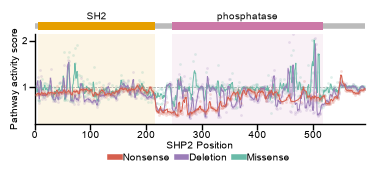

In [10]:
# ── SHP2 activity/domain plot (saved as "2d") — same as 2b, assay=activity. 3.9in x 1.75in. ──
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.transforms import blended_transform_factory

mpl.rcParams['font.family']     = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

PROT     = 'shp2'
PROT_LEN = 593
ASSAY    = 'activity'

WINDOW      = 3
LINE_WIDTH  = 0.7
DOT_SIZE    = 4
BACKBONE_LW = 4
X_PAD       = 10
LABEL_FS    = 7

# Colors matched to the combined abundance/activity figure's variant-class
# palette (mut_colors = ['#4878CF', '#6ABBA8', '#9B7DB8', '#D65F4E'] for
# synonymous / missense / deletion / nonsense). This plot doesn't draw a
# synonymous track, but if you add one later it should be '#4878CF'.
COLOR_SYNONYMOUS = '#4878CF'   # not currently plotted; included for reference
COLOR_MISSENSE   = '#6ABBA8'
COLOR_DELETION   = '#9B7DB8'
COLOR_NONSENSE   = '#D65F4E'

DOMAIN_COLORS = {
    'SH2':         '#E69F00',
    'phosphatase': '#CC79A7',
    'other':       '#CCCCCC',
}
DOMAIN_COL_RENAME = {
    'sh2': 'SH2', 'sh2_1': 'SH2', 'sh2_2': 'SH2',
    'phosphatase': 'phosphatase',
}

prot_scores = Replicate_scores[Replicate_scores['protein'] == PROT].copy()
prot_scores['Position'] = pd.to_numeric(prot_scores['Position'], errors='coerce')

def _position_scores(mut_type):
    sub = prot_scores[
        (prot_scores['Mutation Type'] == mut_type) &
        (prot_scores['assay'] == ASSAY) &
        prot_scores['Position'].notna()
    ].copy()
    sub['Position'] = sub['Position'].astype(int)
    return sub.groupby('Position')['average score'].mean().reset_index().sort_values('Position')

p_ns  = _position_scores('nonsense')
p_del = _position_scores('deletion')
p_mis = _position_scores('missense')

def get_domains_from_scores(gap_threshold=30):
    sub = prot_scores[
        prot_scores['domain'].notna() & (prot_scores['domain'] != 'none')
    ].dropna(subset=['Position']).copy()
    sub['Position'] = sub['Position'].astype(int)
    if len(sub) == 0:
        return pd.DataFrame(columns=['From', 'To', 'domain_label'])

    pos_dom = (
        sub.groupby('Position')['domain']
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={'domain': 'domain_label'})
        .sort_values('Position')
    )
    pos_dom['domain_label'] = pos_dom['domain_label'].map(lambda x: DOMAIN_COL_RENAME.get(x, x))

    rows = []
    pos_arr = pos_dom['Position'].values
    dom_arr = pos_dom['domain_label'].values
    start, current_dom, prev_pos = int(pos_arr[0]), dom_arr[0], int(pos_arr[0])
    for i in range(1, len(pos_arr)):
        pos, dom = int(pos_arr[i]), dom_arr[i]
        if dom != current_dom or pos - prev_pos > gap_threshold:
            rows.append({'From': start, 'To': prev_pos, 'domain_label': current_dom})
            start, current_dom = pos, dom
        prev_pos = pos
    rows.append({'From': start, 'To': prev_pos, 'domain_label': current_dom})
    return pd.DataFrame(rows)

def get_uncovered_regions(pos_list, x_lo, x_hi, gap_threshold=20):
    if not len(pos_list):
        return []
    all_pos = np.array(sorted(set(int(p) for p in pos_list)))
    all_pos = all_pos[(all_pos >= x_lo) & (all_pos <= x_hi)]
    if not len(all_pos):
        return []
    return [(int(all_pos[i]), int(all_pos[i + 1]))
            for i in range(len(all_pos) - 1)
            if all_pos[i + 1] - all_pos[i] > gap_threshold]

doms = get_domains_from_scores()
all_scored = list(p_ns['Position']) + list(p_del['Position']) + list(p_mis['Position'])
x_lo = max(0, min(all_scored) - X_PAD) if all_scored else 0
x_hi = min(PROT_LEN, max(all_scored) + X_PAD) if all_scored else PROT_LEN
uncovered = get_uncovered_regions(all_scored, x_lo, x_hi)
dw = (x_hi - x_lo) * 0.013

FIG_W         = 4.5
FIG_H         = 1.45
LEFT_MARGIN   = 1.00
RIGHT_MARGIN  = 0.20
TOP_PAD       = 0.19
DOM_H         = 0.20
DOM_SCORE_GAP = 0.04
SCORE_H       = 0.90
XLABEL_H      = 0.32
LEGEND_H      = 0.10

COL_W = FIG_W - LEFT_MARGIN - RIGHT_MARGIN
PLOT_CENTER_X = (LEFT_MARGIN + COL_W / 2) / FIG_W

DOM_BAR_H   = 0.65
DOM_GAP_H   = DOM_BAR_H + 0.03
DOM_LABEL_Y = DOM_BAR_H / 2 + 0.035

_HASH_H     = 0.07
_bar_ctr_ax = 0.35 / 1.65
dom_hash_y  = [_bar_ctr_ax - (_HASH_H / DOM_H) / 2,  _bar_ctr_ax + (_HASH_H / DOM_H) / 2]
sc_hash_y   = [-(_HASH_H / SCORE_H) / 2, (_HASH_H / SCORE_H) / 2]

fig_shp2_act = plt.figure(figsize=(FIG_W, FIG_H))
score_bottom_in = XLABEL_H + LEGEND_H
dom_bottom_in   = score_bottom_in + SCORE_H + DOM_SCORE_GAP

ax_dom = fig_shp2_act.add_axes([LEFT_MARGIN / FIG_W, dom_bottom_in   / FIG_H, COL_W / FIG_W, DOM_H   / FIG_H])
ax_sc  = fig_shp2_act.add_axes([LEFT_MARGIN / FIG_W, score_bottom_in / FIG_H, COL_W / FIG_W, SCORE_H / FIG_H])

ax_dom.set_xlim(x_lo, x_hi)
ax_dom.set_ylim(-0.35, 1.30)
ax_dom.axis('off')
ax_dom.plot([x_lo, x_hi], [0, 0], color='#BBBBBB', linewidth=BACKBONE_LW,
            solid_capstyle='butt', zorder=1)

for _, drow in doms.iterrows():
    dlbl = drow['domain_label']
    col  = DOMAIN_COLORS.get(dlbl, DOMAIN_COLORS['other'])
    w    = drow['To'] - drow['From']
    ax_dom.barh(0, w, left=drow['From'], color=col, edgecolor='none',
                linewidth=0, height=DOM_BAR_H, zorder=2)
    mid = drow['From'] + w / 2
    if x_lo <= mid <= x_hi and w / (x_hi - x_lo) > 0.04:
        ax_dom.text(mid, DOM_LABEL_Y, dlbl, ha='center', va='bottom',
                    fontsize=LABEL_FS, color='#111111', clip_on=True)

for uc_s, uc_e in uncovered:
    ax_dom.barh(0, uc_e - uc_s, left=uc_s, facecolor='white', edgecolor='#888888',
                linewidth=0, height=DOM_GAP_H, zorder=4, hatch='////', alpha=0.55)

trans_dom = blended_transform_factory(ax_dom.transData, ax_dom.transAxes)
for edge, cond in [(x_lo, x_lo > 0), (x_hi, x_hi < PROT_LEN)]:
    if cond:
        ax_dom.plot([edge - dw, edge + dw], dom_hash_y, transform=trans_dom,
                    color='#333333', lw=2.0, clip_on=False, zorder=11,
                    solid_capstyle='round')

for _, drow in doms.iterrows():
    col_d = DOMAIN_COLORS.get(drow['domain_label'], DOMAIN_COLORS['other'])
    ax_sc.axvspan(drow['From'], drow['To'], alpha=0.10, color=col_d, zorder=0, linewidth=0)

for uc_s, uc_e in uncovered:
    ax_sc.axvspan(uc_s, uc_e, facecolor='#E8E8E8', edgecolor='#AAAAAA',
                  alpha=0.55, hatch='////', linewidth=0.6, zorder=0.5)

ax_sc.axhline(1.0, color='#888888', linewidth=0.5, linestyle='--', alpha=0.8, zorder=1)

def _smooth(pdata):
    return pdata['average score'].rolling(window=WINDOW, center=True, min_periods=1).mean()

sm_ns, sm_del, sm_mis = _smooth(p_ns), _smooth(p_del), _smooth(p_mis)
smooth_vals = pd.concat([sm_ns, sm_del, sm_mis]).dropna()
if len(smooth_vals):
    ylo, yhi = smooth_vals.min(), smooth_vals.max()
    pad = max((yhi - ylo) * 0.08, 0.05)
    ylim = (ylo - pad, yhi + pad)
else:
    ylim = (-1, 1)

def _plot_line(pdata, sm, color, zorder):
    if not len(pdata):
        return
    ax_sc.scatter(pdata['Position'], pdata['average score'], color=color, s=DOT_SIZE,
                  alpha=0.20, zorder=zorder, linewidths=0, clip_on=True)
    ax_sc.plot(pdata['Position'], sm, color=color, linewidth=LINE_WIDTH, zorder=zorder + 1)

_plot_line(p_mis, sm_mis, COLOR_MISSENSE, 2)
_plot_line(p_del, sm_del, COLOR_DELETION, 4)
_plot_line(p_ns,  sm_ns,  COLOR_NONSENSE, 6)

ax_sc.set_xlim(x_lo, x_hi)
ax_sc.set_ylim(*ylim)
ax_sc.yaxis.set_major_locator(MaxNLocator(nbins=3, steps=[1, 2, 5, 10]))
ax_sc.tick_params(axis='y', labelsize=LABEL_FS, length=4, width=1.0, pad=1, labelleft=True)
ax_sc.tick_params(axis='x', labelsize=LABEL_FS, length=4, width=1.0, pad=1)
ax_sc.set_xlabel('SHP2 Position', fontsize=LABEL_FS, labelpad=1)
ax_sc.set_ylabel('Pathway activity score', fontsize=LABEL_FS, labelpad=2)
ax_sc.spines[['top', 'right']].set_visible(False)
for sp in ax_sc.spines.values():
    sp.set_linewidth(1.0)

trans_sc = blended_transform_factory(ax_sc.transData, ax_sc.transAxes)
for edge, cond in [(x_lo, x_lo > 0), (x_hi, x_hi < PROT_LEN)]:
    if cond:
        ax_sc.plot([edge - dw, edge + dw], sc_hash_y, transform=trans_sc,
                   color='#333333', lw=2.0, clip_on=False, zorder=11,
                   solid_capstyle='round')

mut_handles = [
    Line2D([0], [0], color=COLOR_NONSENSE, linewidth=4.0, label='Nonsense'),
    Line2D([0], [0], color=COLOR_DELETION, linewidth=4.0, label='Deletion'),
    Line2D([0], [0], color=COLOR_MISSENSE, linewidth=4.0, label='Missense'),
]
leg = fig_shp2_act.legend(
    handles=mut_handles, fontsize=LABEL_FS, loc='lower center', ncol=3,
    frameon=False,
    bbox_to_anchor=(PLOT_CENTER_X, -0.02), handlelength=1.0, handleheight=0.7,
    handletextpad=0.3, columnspacing=0.7, borderpad=0.15,
)

plt.savefig(path + '2d.svg', bbox_inches='tight', transparent=True)

Variants in plot:  interdomain=314  buried=15913


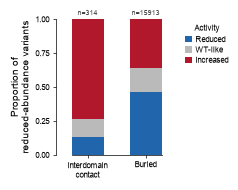

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Stacked bar: activity classification of low-abundance variants,
# split by structural position (interdomain contact vs buried)
# ══════════════════════════════════════════════════════════════════════════════

SASA_BURIED_THRESHOLD = 0.2          # rSASA below this = buried
ABU_TREATMENTS = ['DMSO', 'No_treatment']
ACT_TREATMENTS = ['DMSO', 'No_treatment']
CONTACT_COL    = 'inter_domain_contacts_all_atom'  

# ── Step 1: identify low-abundance missense variants ─────────────────────────
abu_low = Replicate_scores[
    (Replicate_scores['assay'] == 'abundance') &
    (Replicate_scores['assay_treatment'].isin(ABU_TREATMENTS)) &
    (Replicate_scores['classification_2.5pct'] == 'low') &
    (Replicate_scores['Mutation Type'] == 'missense')
][['protein', 'variant', 'library']].drop_duplicates()

# ── Step 2: activity rows for missense variants ───────────────────────────────
act = Replicate_scores[
    (Replicate_scores['assay'] == 'activity') &
    (Replicate_scores['assay_treatment'].isin(ACT_TREATMENTS)) &
    (Replicate_scores['Mutation Type'] == 'missense')
][['protein', 'variant', 'library',
   'classification_2.5pct', CONTACT_COL, 'relative_sasa']
].drop_duplicates(subset=['protein', 'variant', 'library'])

# ── Step 3: keep only low-abundance variants, with activity classification ────
merged = abu_low.merge(act, on=['protein', 'variant', 'library'], how='inner')
merged = merged.dropna(subset=['classification_2.5pct', 'relative_sasa'])

# ── Step 4: assign structural group ──────────────────────────────────────────
merged['group'] = pd.Series(np.nan, index=merged.index, dtype=object)

# NOTE: CONTACT_COL is an actual boolean column (True/False), not the string
# 'yes'/'no' -- comparing it to 'yes' never matched, silently leaving the
# "Interdomain contact" group empty (n=0, NaN bar heights, invisible bar).
merged.loc[merged[CONTACT_COL].astype(bool), 'group'] = 'Interdomain\ncontact'
merged.loc[
    (~merged[CONTACT_COL].astype(bool)) &
    (merged['relative_sasa'] < SASA_BURIED_THRESHOLD),
    'group'
] = 'Buried'

plot_df = merged.dropna(subset=['group'])

interdomain_label = 'Interdomain\ncontact'
n_interdomain = (plot_df['group'] == interdomain_label).sum()
n_buried = (plot_df['group'] == 'Buried').sum()
print(f"Variants in plot:  interdomain={n_interdomain}  buried={n_buried}")

# ── Step 5: compute proportions ───────────────────────────────────────────────
groups   = ['Interdomain\ncontact', 'Buried']
act_cats = ['low', 'wt-like', 'high']   # stacked order: low → bottom, high → top

# Publication-quality ColorBrewer-inspired palette (colorblind-accessible)
colors = {
    'low':    '#2166AC',   # blue  – loss of activity
    'wt-like':'#BABABA',   # neutral gray
    'high':   '#B2182B',   # red   – gain of activity
}

props = {}
counts = {}
for grp in groups:
    sub = plot_df[plot_df['group'] == grp]['classification_2.5pct']
    total = len(sub)
    props[grp]  = {cat: (sub == cat).sum() / total for cat in act_cats}
    counts[grp] = total

# ── Step 6: plot ──────────────────────────────────────────────────────────────
# Publication rcParams
mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':        6,
    'axes.labelsize':   7,
    'axes.titlesize':   6,
    'xtick.labelsize':  6,
    'ytick.labelsize':  6,
    'legend.fontsize':  6,
    'axes.linewidth':   0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size':  2.5,
    'ytick.major.size':  2.5,
    'pdf.fonttype':     42,
    'ps.fonttype':      42,
    'svg.fonttype':     'none',
})

display_labels = {'low': 'Reduced', 'wt-like': 'WT-like', 'high': 'Increased'}

fig, ax = plt.subplots(figsize=(2.25, 1.75))

x         = np.arange(len(groups))
BAR_WIDTH = 0.55
bottoms   = [0.0] * len(groups)

for cat in act_cats:
    vals = [props[grp][cat] for grp in groups]
    bars = ax.bar(x, vals, bottom=bottoms, color=colors[cat], label=display_labels[cat],
                  width=BAR_WIDTH, linewidth=0, zorder=2)
    bottoms = [b + v for b, v in zip(bottoms, vals)]

# n labels ABOVE the bars (bars are proportions, so they all reach y=1)
for i, grp in enumerate(groups):
    ax.text(i, 1.02, f'n={counts[grp]}', ha='center', va='bottom',
            fontsize=5, color='#444444')

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=6)
ax.set_ylabel('Proportion of\nreduced-abundance variants', fontsize=7, labelpad=3)
ax.set_ylim(0, 1)
ax.set_xlim(-0.55, len(groups) - 0.45)
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.25))
ax.tick_params(axis='both', which='both', pad=2)

leg = ax.legend(
    title='Activity',
    bbox_to_anchor=(1.03, 1),
    loc='upper left',
    frameon=False,
    handlelength=0.8,
    handleheight=0.8,
    handletextpad=0.4,
    borderpad=0,
    labelspacing=0.3,
)
leg.get_title().set_fontsize(6)
leg.get_title().set_linespacing(1.3)

# NOTE: sns.despine(trim=True) trims each spine to the tick positions. The
# x-ticks sit at the bar *centers*, so a trimmed bottom spine only spans
# from the center of the first bar to the center of the last one -- it
# doesn't reach either bar's outer edge, which read as "ending in the
# middle of the bars." Turning trim off and setting explicit spine bounds
# makes the bottom spine span the bars' full outer width, and the left
# spine span the full 0-1 proportion range.
sns.despine(ax=ax, trim=False)
ax.spines['left'].set_bounds(0, 1)
ax.spines['bottom'].set_bounds(x[0] - BAR_WIDTH / 2, x[-1] + BAR_WIDTH / 2)

plt.tight_layout(pad=0.3)

plt.savefig(path + '2f.svg', bbox_inches='tight', transparent=True)


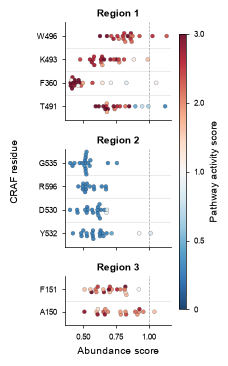

In [11]:
# ── CRAF cluster plot — Nature publication quality ────────────────────────────
# Clusters stacked vertically (instead of side-by-side); each panel now plots
# Abundance score on the x-axis and residue position on the y-axis (instead
# of the other way around).

import matplotlib as mpl
import matplotlib.colors as mcolors

# ── Nature rcParams ────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'font.family':        'sans-serif',
    'font.sans-serif':    ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':          7,
    'axes.labelsize':     7,
    'axes.titlesize':     7,
    'xtick.labelsize':    6,
    'ytick.labelsize':    6,
    'xtick.major.size':   2.5,
    'ytick.major.size':   2.5,
    'xtick.major.width':  0.5,
    'ytick.major.width':  0.5,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'axes.linewidth':     0.5,
    'pdf.fonttype':       42,
    'svg.fonttype':       'none',
})

GROUPS = [
    [496, 493, 360, 491],  # Cluster 1
    [535, 596, 530, 532],  # Cluster 2
    [151, 150],             # Cluster 3
]
ALL_POSITIONS = [p for g in GROUPS for p in g]

# ── 1. Filter ──────────────────────────────────────────────────────────────────
mask = (
    (Replicate_scores['protein'] == 'craf') &
    (Replicate_scores['Mutation Type'] == 'missense') &
    (Replicate_scores['assay_treatment'].isin(['DMSO', 'No_treatment'])) &
    (pd.to_numeric(Replicate_scores['Position'], errors='coerce').isin(ALL_POSITIONS))
)
sub = Replicate_scores[mask].copy()
sub['Position'] = pd.to_numeric(sub['Position'], errors='coerce').astype(int)

# ── 2. Per-variant abundance and activity ──────────────────────────────────────
abu = (sub[sub['assay'] == 'abundance']
       .groupby(['variant', 'Position'])['average score']
       .mean().reset_index()
       .rename(columns={'average score': 'abundance'}))

act = (sub[sub['assay'] == 'activity']
       .groupby(['variant', 'Position'])['average score']
       .mean().reset_index()
       .rename(columns={'average score': 'activity'}))

merged = abu.merge(act, on=['variant', 'Position'], how='inner')

# WT residue labels (e.g. "L535")
wt_res = (sub[['Position', 'Wild Type Residue']]
          .drop_duplicates()
          .set_index('Position')['Wild Type Residue']
          .to_dict())

# ── 3. Beeswarm helper ─────────────────────────────────────────────────────────
# Generic: given the continuous coordinate (abundance, now plotted on x),
# returns a perpendicular jitter offset (now applied to the y/category
# position) so points close together on the continuous axis don't overlap.
def beeswarm_offset(group_val, dot_r_val, dot_r_step=0.06):
    if len(group_val) == 0:
        return np.array([])
    order  = np.argsort(group_val)
    v_sort = group_val[order]
    offs   = np.zeros(len(group_val))
    placed = []
    for i, v in enumerate(v_sort):
        best_off = 0.0
        for layer in range(60):
            candidates = [0.0] if layer == 0 else [layer * dot_r_step, -layer * dot_r_step]
            found = False
            for ot in candidates:
                ok = all(
                    abs(ot - po) >= dot_r_step * 1.6 or abs(v - pv) >= dot_r_val
                    for po, pv in placed
                )
                if ok:
                    best_off = ot
                    found    = True
                    break
            if found:
                break
        placed.append((best_off, v))
        offs[order[i]] = best_off
    return offs

abu_all  = merged['abundance'].values
val_span = abu_all.max() - abu_all.min() or 1.0
dot_r_val = val_span * 0.025

pos_offset = {}
for pos, grp in merged.groupby('Position'):
    pos_offset[pos] = beeswarm_offset(grp['abundance'].values, dot_r_val=dot_r_val)

# ── 4. Colour scale ────────────────────────────────────────────────────────────
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=3)
cmap = plt.cm.RdBu_r
CBAR_TICKS = [0, 0.5, 1.0, 2.0, 3.0]

# ── 5. Figure — 3 rows (one per cluster), stacked vertically ──────────────────
MM = 1 / 25.4
FIG_W, FIG_H = 45 * MM, 100 * MM

heights = [len(g) for g in GROUPS]
fig, axes = plt.subplots(
    3, 1, figsize=(FIG_W, FIG_H),
    gridspec_kw={'height_ratios': heights, 'hspace': 0.35},
    sharex=True
)

sc_last = None
for ax_i, (ax, group_pos) in enumerate(zip(axes, GROUPS)):
    for yi, pos in enumerate(group_pos):
        grp = merged[merged['Position'] == pos]
        if grp.empty:
            continue
        sc_last = ax.scatter(
            grp['abundance'].values, yi + pos_offset[pos],
            c=grp['activity'].values.clip(0.25, 3), cmap=cmap, norm=norm,
            s=8, alpha=0.90, edgecolors='#222222', linewidths=0.15, zorder=3
        )

    ax.axvline(1.0, color='#999999', linewidth=0.5, linestyle='--', alpha=0.9, zorder=1)

    for i in range(len(group_pos) - 1):
        ax.axhline(i + 0.5, color='#E8E8E8', linewidth=0.6, zorder=0)

    tick_labels = [f"{wt_res.get(p, '')}{p}" for p in group_pos]
    ax.set_yticks(range(len(group_pos)))
    ax.set_yticklabels(tick_labels, fontsize=6)
    ax.set_ylim(-0.6, len(group_pos) - 0.4)
    ax.invert_yaxis()   # first residue in the list reads at the top

    ax.set_title(f'Region {ax_i + 1}', fontsize=7, fontweight='bold', pad=4)

    if ax_i == len(GROUPS) - 1:
        ax.set_xlabel('Abundance score', fontsize=7)
    else:
        ax.tick_params(labelbottom=False)

    sns.despine(ax=ax)
    for sp in ax.spines.values():
        sp.set_linewidth(0.5)

# Shared y-axis label (rotated, to the left of all 3 stacked panels)
fig.text(-0.06, 0.5, 'CRAF residue', ha='right', va='center', fontsize=7, rotation=90)

# ── 6. Colorbar ────────────────────────────────────────────────────────────────
fig.subplots_adjust(right=0.80, left=0.20)
cbar_ax = fig.add_axes([0.84, 0.15, 0.04, 0.70])
cbar = fig.colorbar(sc_last, cax=cbar_ax)
cbar.set_label('Pathway activity score', fontsize=7, labelpad=4)
cbar.set_ticks(CBAR_TICKS)
cbar.set_ticklabels([str(t) for t in CBAR_TICKS], fontsize=6)
cbar.outline.set_linewidth(0.5)

plt.savefig(path + '2g.svg', bbox_inches='tight', transparent=True)

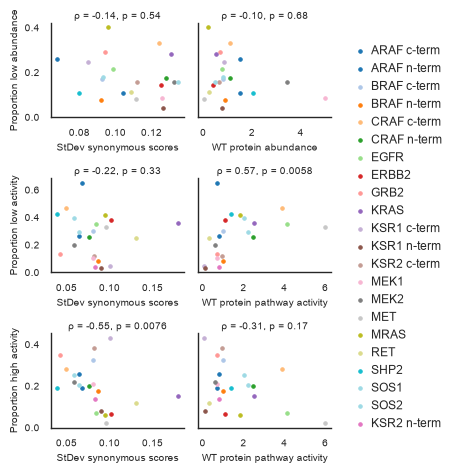

In [12]:
TREATMENTS = ['DMSO', 'No_treatment']  
  
def lib_label(lib):  
    if '_cterm' in lib:  
        return lib.replace('_cterm', '').upper() + ' c-term'  
    elif '_nterm' in lib:  
        return lib.replace('_nterm', '').upper() + ' n-term'  
    return lib.upper()  
  
def build_scatter_df(assay):  
    df_missense = Replicate_scores[  
        (Replicate_scores['assay'] == assay) &  
        (Replicate_scores['Mutation Type'] == 'missense') &  
        (Replicate_scores['assay_treatment'].isin(TREATMENTS))  
    ]  
    df_synon = Replicate_scores[  
        (Replicate_scores['assay'] == assay) &  
        (Replicate_scores['Mutation Type'] == 'synonymous wild type') &  
        (Replicate_scores['assay_treatment'].isin(TREATMENTS))  
    ]  
  
    low_high_df = (  
        df_missense.groupby('library')  
        .apply(lambda g: pd.Series({  
            'low_fraction':  (g['classification_2.5pct'] == 'low').sum()  / len(g),  
            'high_fraction': (g['classification_2.5pct'] == 'high').sum() / len(g),  
        }))  
        .reset_index()  
    )  
  
    stdev_df = (  
        df_synon.groupby(['library', 'assay_treatment'])['average score']  
        .std().reset_index()  
        .rename(columns={'average score': 'synon_WT_stdev'})  
        .groupby('library')['synon_WT_stdev'].mean().reset_index()  
    )  
  
    wt_df = (  
        Replicate_scores[  
            (Replicate_scores['assay'] == assay) &  
            (Replicate_scores['variant'] == 'WT') &  
            (Replicate_scores['assay_treatment'].isin(TREATMENTS))  
        ]  
        .groupby(['library', 'assay_treatment'])['intercept_0_standard-adjusted score']  
        .mean().reset_index()  
        .groupby('library')['intercept_0_standard-adjusted score'].mean().reset_index()  
        .rename(columns={'intercept_0_standard-adjusted score': 'wt_score'})  
    )  
  
    out = low_high_df.merge(stdev_df, on='library').merge(wt_df, on='library')  
    out['label'] = out['library'].apply(lib_label)  
    return out  
  
scatter_df_abund = build_scatter_df('abundance')  
scatter_df_act   = build_scatter_df('activity')  
  
# ── Shared colour palette across both assays ────────────────────────────────  
libs_sorted = sorted(set(scatter_df_abund['library']) | set(scatter_df_act['library']))  
cmap    = mpl.colormaps['tab20'].resampled(len(libs_sorted))  
palette = {lib: cmap(i) for i, lib in enumerate(libs_sorted)}  
  
# ── Style ────────────────────────────────────────────────────────────────────  
mpl.rcParams['font.family']     = 'sans-serif'  
mpl.rcParams['font.sans-serif'] = ['Arial']  
mpl.rcParams['svg.fonttype']    = 'none'  
sns.set(style='white')  
sns.set_context('paper')  
  
# ── Figure: 3 rows x 2 cols ──────────────────────────────────────────────────  
fig, axes = plt.subplots(3, 2, figsize=(3.5, 4.8), sharey='row')  
  
panels = [  
    # (ax,          df,                xcol,             ycol,           xlabel,                  ylabel)  
    (axes[0, 0], scatter_df_abund, 'synon_WT_stdev', 'low_fraction',  'StDev synonymous scores',  'Proportion low abundance'),  
    (axes[0, 1], scatter_df_abund, 'wt_score',        'low_fraction',  'WT protein abundance', ''),  
    (axes[1, 0], scatter_df_act,   'synon_WT_stdev', 'low_fraction',  'StDev synonymous scores',  'Proportion low activity'),  
    (axes[1, 1], scatter_df_act,   'wt_score',        'low_fraction',  'WT protein pathway activity', ''),  
    (axes[2, 0], scatter_df_act,   'synon_WT_stdev', 'high_fraction', 'StDev synonymous scores',  'Proportion high activity'),  
    (axes[2, 1], scatter_df_act,   'wt_score',        'high_fraction', 'WT protein pathway activity', ''),  
]  
  
for ax, df, xcol, ycol, xlabel, ylabel in panels:  
    for _, row in df.iterrows():  
        ax.scatter(row[xcol], row[ycol],  
                   color=palette[row['library']], s=6, zorder=3,  
                   label=row['label'])  
  
    rho, p = spearmanr(df[xcol], df[ycol])  
    p_str  = 'p < 0.001' if p < 0.001 else f'p = {p:.2g}'  
    ax.set_title(f'ρ = {rho:.2f}, {p_str}', fontsize=7, pad=3)  
  
    ax.set_xlabel(xlabel, fontsize=7)  
    ax.set_ylabel(ylabel, fontsize=7)  
    ax.tick_params(axis='both', labelsize=7)
    ax.set_ylim(bottom=0)  
    sns.despine(ax=ax)  
  
# ── Single shared legend, outside right ──────────────────────────────────────  
seen, handles, labels_out = set(), [], []  
for ax in axes.flat:  
    for h, lbl in zip(*ax.get_legend_handles_labels()):  
        if lbl not in seen:  
            seen.add(lbl)  
            handles.append(h)  
            labels_out.append(lbl)  
  
fig.legend(handles, labels_out,  
           bbox_to_anchor=(1.01, 0.5), loc='center left',  
           frameon=False, ncol=1,  
           handlelength=0.8, handletextpad=0.5, borderpad=0)  
  
plt.tight_layout()  
plt.savefig(path + 'ED 3a.svg', bbox_inches='tight', transparent=True)


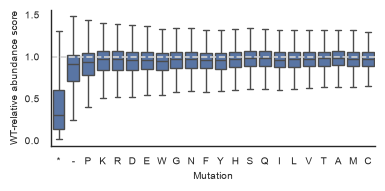

In [13]:
subset = Replicate_scores[  
    (Replicate_scores['assay'] == 'abundance')  
    & ((Replicate_scores['assay_treatment'] == 'DMSO') | (Replicate_scores['assay_treatment'] == 'No_treatment'))  
    & (Replicate_scores['Mutation Type'].isin(['deletion', 'missense', 'nonsense']))  
    & (~Replicate_scores['Mutation'].str.contains('delins', case=False, na=False))  
].copy()  

# Compute IQR per mutation
effect_df = (
    subset
    .groupby('Mutation')['average score']
    .quantile([0.25, 0.75])
    .unstack()
)

effect_df['effect_size'] = effect_df[0.75] - effect_df[0.25]

# Order mutations by largest effect → smallest
orders = (
    effect_df
    .sort_values('effect_size', ascending=False)
    .index
    .tolist()
)

plt.figure(figsize=(4, 2))
sns.boxplot(
    data=subset,
    x='Mutation',
    y='average score',
    showfliers=False,
    order=orders
)

plt.xlabel('Mutation', fontsize=7)
plt.ylabel('WT-relative abundance score', fontsize=7)
# plt.title('Abundance', fontsize=14)
plt.xticks(rotation=0)
plt.axhline(y=1, color='lightgray', linestyle='--')
plt.tick_params(axis='both', labelsize=7)   # <- controls tick label font size  
# plt.ylim(0, 2)
sns.despine()  
plt.tight_layout()

plt.savefig(path + 'ED 3b.svg', bbox_inches='tight', transparent=True)


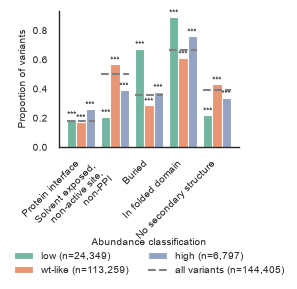

In [14]:
from matplotlib.lines import Line2D

# Force Helvetica everywhere
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

# ================================
# Filter to relevant variants
# ================================
df = Replicate_scores[
    (Replicate_scores["assay"] == "abundance")
    & (Replicate_scores["Mutation Type"] == "missense")
    & (Replicate_scores["assay_treatment"].isin(["DMSO", "No_treatment"]))
].copy()

df["abd_class"] = df["classification_2.5pct"].map({
    "low": "low",
    "wt-like": "wt-like",
    "high": "high"
})

all_variants = df.copy()
low     = df[df["abd_class"] == "low"].copy()
wt_like = df[df["abd_class"] == "wt-like"].copy()
high    = df[df["abd_class"] == "high"].copy()

groups = {
    "all variants": all_variants,
    "low":    low,
    "wt-like": wt_like,
    "high":   high,
}
group_sizes = {label: len(g) for label, g in groups.items()}

abd_order = ["low", "wt-like", "high"]

# ================================
# Feature flags
# ================================
df["Active site"] = df["active_site"] == True
df["Protein interface"] = df["interface_pdb_curated"] == True
df["Solvent exposed, \n non-active site, \n non-PPI"] = (
    (~df["Active site"]) & (~df["Protein interface"]) & (df["relative_sasa"] >= 0.2)
)
df["Buried"] = df["relative_sasa"] < 0.2
df["In folded domain"] = df["domain"] != "none"
df["No secondary structure"] = df['dssp_secondary_structure'] == "no_ss"

feature_cols = [
    # "Active site",
    "Protein interface",
    "Solvent exposed, \n non-active site, \n non-PPI",
    "Buried",
    "In folded domain",
    "No secondary structure",
]

for key in groups:
    groups[key] = groups[key].merge(
        df[["library", "variant"] + feature_cols],
        on=["library", "variant"], how="left"
    )

# ================================
# Compute fractions
# ================================
records = []
for label, g in groups.items():
    for feature in feature_cols:
        records.append({
            "classification": label,
            "feature": feature,
            "fraction": g[feature].mean()
        })

plot_df = pd.DataFrame(records)

ref_df = plot_df[plot_df["classification"] == "all variants"].copy()
bar_df = plot_df[plot_df["classification"] != "all variants"].copy()

bar_order = ["low", "wt-like", "high"]
bar_df["classification"] = pd.Categorical(
    bar_df["classification"], categories=bar_order, ordered=True
)

# ================================
# Permutation tests
# ================================
def permutation_test_fraction(group_df, random_df, feature, n_perm=100, seed=0):
    rng = np.random.default_rng(seed)
    n = len(group_df)
    obs = group_df[feature].mean()
    null_fracs = np.array([
        random_df.sample(n, replace=False, random_state=rng.integers(1e9))[feature].mean()
        for _ in range(n_perm)
    ])
    pval = np.mean(np.abs(null_fracs - null_fracs.mean()) >= np.abs(obs - null_fracs.mean()))
    return {"observed_fraction": obs, "null_mean": null_fracs.mean(), "p_value": pval}

def pval_to_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

results = []
random_df = groups["all variants"]
for label, g in groups.items():
    if label == "all variants":
        continue
    for feature in feature_cols:
        out = permutation_test_fraction(g, random_df, feature)
        results.append({"classification": label, "feature": feature, **out})

stats_df = pd.DataFrame(results)
stats_df["n"] = stats_df.apply(lambda r: len(groups[r["classification"]]), axis=1)

# ================================
# Plot
# ================================
sns.set_style("white")
fig, ax = plt.subplots(figsize=(2.8, 4))

sns.barplot(
    data=bar_df,
    x="feature", y="fraction", hue="classification",
    hue_order=bar_order,
    palette="Set2", ax=ax,
    width=0.8
)

# ── Dashed reference lines ────────────────────────────────────────────────────
group_width = 0.8
for i, feature in enumerate(feature_cols):
    y = ref_df[ref_df["feature"] == feature]["fraction"].values[0]
    ax.hlines(y, i - group_width / 2, i + group_width / 2,
              colors="gray", linestyles="dashed", linewidth=1.5, zorder=5)

# ── Significance stars ────────────────────────────────────────────────────────
for patch, (_, row) in zip(ax.patches, bar_df.iterrows()):
    stat = stats_df[
        (stats_df["classification"] == row["classification"]) &
        (stats_df["feature"] == row["feature"])
    ]
    if stat.empty:
        continue
    stars = pval_to_stars(stat["p_value"].iloc[0])
    if stars != "ns":
        ax.text(patch.get_x() + patch.get_width() / 2,
                patch.get_height() + 0.01,
                stars, ha="center", va="bottom", fontsize=5, fontweight="bold")

# ── X-axis: 45° labels, no axis title ────────────────────────────────────────
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha='right', fontsize=7)
ax.set_ylabel("Proportion of variants", fontsize=7)

ax.tick_params(axis='y', labelsize=7)

# ── Legend below plot, 2 columns ─────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
new_labels = [f"{l} (n={group_sizes[l]:,})" for l in labels]
ref_line = Line2D([0], [0], color="gray", linestyle="dashed", linewidth=1.5)
handles.append(ref_line)
new_labels.append(f"all variants (n={group_sizes['all variants']:,})")

legend = ax.legend(
    handles, new_labels,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.6),
    ncol=2,
    title="Abundance classification",
    fontsize=7,
)
legend.get_title().set_fontsize(7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(path + 'ED 3c.svg', bbox_inches='tight', transparent=True)


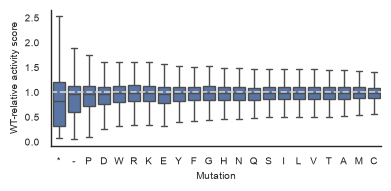

In [15]:
subset = Replicate_scores[  
    (Replicate_scores['assay'] == 'activity')  
    & ((Replicate_scores['assay_treatment'] == 'DMSO') | (Replicate_scores['assay_treatment'] == 'No_treatment'))  
    & (Replicate_scores['Mutation Type'].isin(['deletion', 'missense', 'nonsense']))  
    & (~Replicate_scores['Mutation'].str.contains('delins', case=False, na=False))  
].copy()  

# Compute IQR per mutation
effect_df = (
    subset
    .groupby('Mutation')['average score']
    .quantile([0.25, 0.75])
    .unstack()
)

effect_df['effect_size'] = effect_df[0.75] - effect_df[0.25]

# Order mutations by largest effect → smallest
orders = (
    effect_df
    .sort_values('effect_size', ascending=False)
    .index
    .tolist()
)

plt.figure(figsize=(4, 2))
sns.boxplot(
    data=subset,
    x='Mutation',
    y='average score',
    showfliers=False,
    order=orders
)

plt.xlabel('Mutation', fontsize=7)
plt.ylabel('WT-relative activity score', fontsize=7)
# plt.title('Abundance', fontsize=14)
plt.xticks(rotation=0)
plt.axhline(y=1, color='lightgray', linestyle='--')
plt.tick_params(axis='both', labelsize=7)   # <- controls tick label font size  
# plt.ylim(0, 2)
sns.despine()  
plt.tight_layout()

plt.savefig(path + 'ED 3d.svg', bbox_inches='tight', transparent=True)

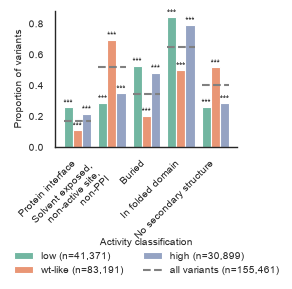

In [16]:
from matplotlib.lines import Line2D

# Force Helvetica everywhere
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'

# ================================
# Filter to relevant variants
# ================================
df = Replicate_scores[
    (Replicate_scores["assay"] == "activity")
    & (Replicate_scores["Mutation Type"] == "missense")
    & (Replicate_scores["assay_treatment"].isin(["DMSO", "No_treatment"]))
].copy()

df["abd_class"] = df["classification_2.5pct"].map({
    "low": "low",
    "wt-like": "wt-like",
    "high": "high"
})

all_variants = df.copy()
low     = df[df["abd_class"] == "low"].copy()
wt_like = df[df["abd_class"] == "wt-like"].copy()
high    = df[df["abd_class"] == "high"].copy()

groups = {
    "all variants": all_variants,
    "low":    low,
    "wt-like": wt_like,
    "high":   high,
}
group_sizes = {label: len(g) for label, g in groups.items()}

abd_order = ["low", "wt-like", "high"]

# ================================
# Feature flags
# ================================
df["Active site"] = df["active_site"] == True
df["Protein interface"] = df["interface_pdb_curated"] == True
df["Solvent exposed, \n non-active site, \n non-PPI"] = (
    (~df["Active site"]) & (~df["Protein interface"]) & (df["relative_sasa"] >= 0.2)
)
df["Buried"] = df["relative_sasa"] < 0.2
df["In folded domain"] = df["domain"] != "none"
df["No secondary structure"] = df['dssp_secondary_structure'] == "no_ss"

feature_cols = [
    # "Active site",
    "Protein interface",
    "Solvent exposed, \n non-active site, \n non-PPI",
    "Buried",
    "In folded domain",
    "No secondary structure",
]

for key in groups:
    groups[key] = groups[key].merge(
        df[["library", "variant"] + feature_cols],
        on=["library", "variant"], how="left"
    )

# ================================
# Compute fractions
# ================================
records = []
for label, g in groups.items():
    for feature in feature_cols:
        records.append({
            "classification": label,
            "feature": feature,
            "fraction": g[feature].mean()
        })

plot_df = pd.DataFrame(records)

ref_df = plot_df[plot_df["classification"] == "all variants"].copy()
bar_df = plot_df[plot_df["classification"] != "all variants"].copy()

bar_order = ["low", "wt-like", "high"]
bar_df["classification"] = pd.Categorical(
    bar_df["classification"], categories=bar_order, ordered=True
)

# ================================
# Permutation tests
# ================================
def permutation_test_fraction(group_df, random_df, feature, n_perm=100, seed=0):
    rng = np.random.default_rng(seed)
    n = len(group_df)
    obs = group_df[feature].mean()
    null_fracs = np.array([
        random_df.sample(n, replace=False, random_state=rng.integers(1e9))[feature].mean()
        for _ in range(n_perm)
    ])
    pval = np.mean(np.abs(null_fracs - null_fracs.mean()) >= np.abs(obs - null_fracs.mean()))
    return {"observed_fraction": obs, "null_mean": null_fracs.mean(), "p_value": pval}

def pval_to_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

results = []
random_df = groups["all variants"]
for label, g in groups.items():
    if label == "all variants":
        continue
    for feature in feature_cols:
        out = permutation_test_fraction(g, random_df, feature)
        results.append({"classification": label, "feature": feature, **out})

stats_df = pd.DataFrame(results)
stats_df["n"] = stats_df.apply(lambda r: len(groups[r["classification"]]), axis=1)

# ================================
# Plot
# ================================
sns.set_style("white")
fig, ax = plt.subplots(figsize=(2.8, 4))

sns.barplot(
    data=bar_df,
    x="feature", y="fraction", hue="classification",
    hue_order=bar_order,
    palette="Set2", ax=ax,
    width=0.8
)

# ── Dashed reference lines ────────────────────────────────────────────────────
group_width = 0.8
for i, feature in enumerate(feature_cols):
    y = ref_df[ref_df["feature"] == feature]["fraction"].values[0]
    ax.hlines(y, i - group_width / 2, i + group_width / 2,
              colors="gray", linestyles="dashed", linewidth=1.5, zorder=5)

# ── Significance stars ────────────────────────────────────────────────────────
for patch, (_, row) in zip(ax.patches, bar_df.iterrows()):
    stat = stats_df[
        (stats_df["classification"] == row["classification"]) &
        (stats_df["feature"] == row["feature"])
    ]
    if stat.empty:
        continue
    stars = pval_to_stars(stat["p_value"].iloc[0])
    if stars != "ns":
        ax.text(patch.get_x() + patch.get_width() / 2,
                patch.get_height() + 0.01,
                stars, ha="center", va="bottom", fontsize=5, fontweight="bold")

# ── X-axis: 45° labels, no axis title ────────────────────────────────────────
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha='right', fontsize=7)
ax.set_ylabel("Proportion of variants", fontsize=7)

ax.tick_params(axis='y', labelsize=7)

# ── Legend below plot, 2 columns ─────────────────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
new_labels = [f"{l} (n={group_sizes[l]:,})" for l in labels]
ref_line = Line2D([0], [0], color="gray", linestyle="dashed", linewidth=1.5)
handles.append(ref_line)
new_labels.append(f"all variants (n={group_sizes['all variants']:,})")

legend = ax.legend(
    handles, new_labels,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.6),
    ncol=2,
    title="Activity classification",
    fontsize=7,
)
legend.get_title().set_fontsize(7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(path + 'ED 3e.svg', bbox_inches='tight', transparent=True)


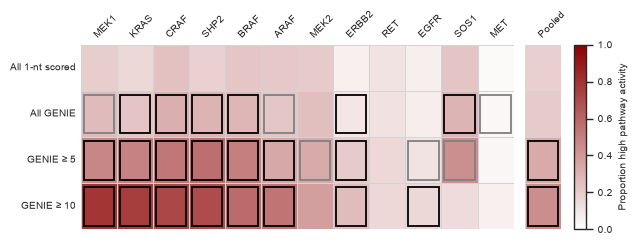

In [17]:
# ── Heatmap: fraction of missense variants classified "high" (activity assay) ──
# Filters: assay == 'activity', assay_treatment in {DMSO, No_treatment}, Mutation Type == 'missense'
# Columns: one per protein (only proteins with >=1 variant at genie_count >= 10), sorted greatest -> least
#          by the "GENIE >= 10" row, plus a pooled "Pooled" column (not sorted, always last)
# Rows: variant-count / nt-change filters
# Color: white -> dark red, encoding fraction with classification_2.5pct == 'high'
# Box outlines: per protein (and for the Pooled column, across all proteins) x per row EXCEPT
#   "All 1-nt scored", Fisher's exact test asking whether variants meeting that row's threshold
#   (e.g. genie_count >= 10) are enriched for 'high' classification relative to the rest of that
#   protein's (or, for Pooled, the rest of the whole dataset's) missense variants (2x2 table,
#   one-sided, testing enrichment only). p < 0.05 -> gray box, p < 0.01 -> black box, drawn
#   slightly inset from the cell edge.

from matplotlib.patches import Rectangle
from scipy.stats import fisher_exact

TREATMENTS = ['DMSO', 'No_treatment']

act_missense = Replicate_scores[
    (Replicate_scores['assay'] == 'activity') &
    (Replicate_scores['assay_treatment'].isin(TREATMENTS))
].copy()

# Only keep proteins that have at least one variant in the genie_count >= 10 bin
genie10_counts = (
    act_missense[act_missense['genie_count'] >= 10.0]
    .groupby('protein').size()
)
candidate_proteins = [
    p for p in act_missense['protein'].dropna().unique()
    if genie10_counts.get(p, 0) >= 1
]

row_defs = [
    ('All 1-nt scored', lambda d: d['min_nt_changes'] == 1.0),
    ('All GENIE',       lambda d: d['genie_count'] > 0.0),
    ('GENIE ≥ 5',       lambda d: d['genie_count'] >= 5.0),
    ('GENIE ≥ 10',      lambda d: d['genie_count'] >= 10.0),
]

def high_fraction(d):
    return (d['classification_2.5pct'] == 'high').sum() / len(d) if len(d) else np.nan

# Fraction of 'high' per (row, protein), before sorting columns
_unsorted = pd.DataFrame(
    index=[r[0] for r in row_defs],
    columns=[p.upper() for p in candidate_proteins],
    dtype=float,
)
for row_label, row_filter in row_defs:
    row_df = act_missense[row_filter(act_missense)]
    for prot in candidate_proteins:
        _unsorted.loc[row_label, prot.upper()] = high_fraction(row_df[row_df['protein'] == prot])

# Sort protein columns greatest -> least by the "GENIE >= 10" row
sort_row = row_defs[-1][0]
protein_cols = _unsorted.loc[sort_row].sort_values(ascending=False).index.tolist()
proteins = [c.lower() for c in protein_cols]
col_labels = protein_cols + ['Pooled']

heat_data = pd.DataFrame(index=[r[0] for r in row_defs], columns=col_labels, dtype=float)
heat_data[protein_cols] = _unsorted[protein_cols]
for row_label, row_filter in row_defs:
    row_df = act_missense[row_filter(act_missense)]
    heat_data.loc[row_label, 'Pooled'] = high_fraction(row_df)

# ── Per-cell Fisher's exact enrichment test (skip "All 1-nt scored"; include Pooled) ────────
def fisher_p(in_grp, out_grp):
    if min(len(in_grp), len(out_grp)) == 0:
        return np.nan
    a = (in_grp['classification_2.5pct'] == 'high').sum(); b = len(in_grp) - a
    c = (out_grp['classification_2.5pct'] == 'high').sum(); d = len(out_grp) - c
    _, p = fisher_exact([[a, b], [c, d]], alternative='greater')
    return p

test_row_defs = [rd for rd in row_defs if rd[0] != 'All 1-nt scored']
pvals = pd.DataFrame(index=[r[0] for r in test_row_defs], columns=col_labels, dtype=float)

for row_label, row_filter in test_row_defs:
    for prot, col in zip(proteins, protein_cols):
        prot_df = act_missense[act_missense['protein'] == prot]
        in_mask = row_filter(prot_df)
        pvals.loc[row_label, col] = fisher_p(prot_df[in_mask], prot_df[~in_mask])
    in_mask = row_filter(act_missense)
    pvals.loc[row_label, 'Pooled'] = fisher_p(act_missense[in_mask], act_missense[~in_mask])

cmap_white_darkred = mpl.colors.LinearSegmentedColormap.from_list(
    'white_darkred', ['#FFFFFF', '#8B0000']
)

n_prot = len(protein_cols)
fig, (ax_main, ax_pool) = plt.subplots(
    1, 2,
    figsize=(0.4 * (n_prot + 1) + 1, 2.4),
    gridspec_kw={'width_ratios': [n_prot, 1], 'wspace': 0.05},
)

sns.heatmap(
    heat_data[protein_cols],
    cmap=cmap_white_darkred,
    vmin=0, vmax=1,
    annot=False,
    linewidths=0.5, linecolor='lightgray',
    cbar=False,
    ax=ax_main,
)
sns.heatmap(
    heat_data[['Pooled']],
    cmap=cmap_white_darkred,
    vmin=0, vmax=1,
    annot=False,
    linewidths=0.5, linecolor='lightgray',
    cbar=False,
    ax=ax_pool,
    yticklabels=False,
)

LABEL_FONTSIZE = 7
for ax in (ax_main, ax_pool):
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='both', length=0, labelsize=LABEL_FONTSIZE)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='left', rotation_mode='anchor', fontsize=LABEL_FONTSIZE)

plt.setp(ax_main.get_yticklabels(), rotation=0, fontsize=LABEL_FONTSIZE)

# Box significant cells, inset slightly so the box sits just inside the cell border
BOX_MARGIN = 0.08
for i, row_label in enumerate(heat_data.index):
    if row_label not in pvals.index:
        continue
    for j, col in enumerate(protein_cols):
        p = pvals.loc[row_label, col]
        if pd.isna(p):
            continue
        edgecolor = 'black' if p < 0.01 else ('gray' if p < 0.05 else None)
        if edgecolor is None:
            continue
        ax_main.add_patch(Rectangle(
            (j + BOX_MARGIN, i + BOX_MARGIN), 1 - 2 * BOX_MARGIN, 1 - 2 * BOX_MARGIN,
            fill=False, edgecolor=edgecolor, linewidth=1.3, clip_on=False,
        ))
    p_pooled = pvals.loc[row_label, 'Pooled']
    if not pd.isna(p_pooled):
        edgecolor = 'black' if p_pooled < 0.01 else ('gray' if p_pooled < 0.05 else None)
        if edgecolor is not None:
            ax_pool.add_patch(Rectangle(
                (BOX_MARGIN, i + BOX_MARGIN), 1 - 2 * BOX_MARGIN, 1 - 2 * BOX_MARGIN,
                fill=False, edgecolor=edgecolor, linewidth=1.3, clip_on=False,
            ))

plt.tight_layout()

# Colorbar (legend) sized to match the heatmap's height exactly, placed just right of Pooled
pool_pos = ax_pool.get_position()
cbar_ax = fig.add_axes([pool_pos.x1 + 0.02, pool_pos.y0, 0.02, pool_pos.height])
cb = fig.colorbar(ax_pool.collections[0], cax=cbar_ax)
cb.set_label("Proportion high pathway activity", fontsize=LABEL_FONTSIZE)
cb.ax.tick_params(labelsize=LABEL_FONTSIZE)

plt.savefig(path + 'ED 3f.svg', bbox_inches='tight', transparent=True)

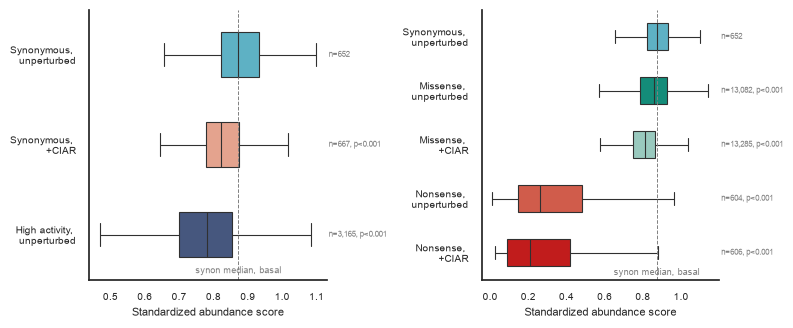

In [18]:
# ── BRAF abundance boxplot: reference groups vs. high-activity missense variants ──
# Two panels, side by side (figure is 8" wide total):
#   Left:  synonymous WT (basal, +CIAR) vs. high-activity missense (basal)
#   Right: synonymous WT (basal) vs. missense (basal, +CIAR) vs. nonsense (basal, +CIAR)

braf_long = Replicate_scores[Replicate_scores['protein'] == 'braf'].copy()

braf_static = (
    braf_long[['variant', 'Mutation Type']]
    .drop_duplicates(subset=['variant'])
    .reset_index(drop=True)
)

braf_pivot = (
    braf_long[
        (braf_long['assay'] == 'abundance') &
        (braf_long['assay_treatment'].isin(['No_treatment', 'CIAR']))
    ]
    .pivot_table(
        index='variant',
        columns='assay_treatment',
        values='intercept_0_standard-adjusted score',
        aggfunc='first',
    )
    .add_prefix('abundance_std_adj__')
    .reset_index()
)

braf = braf_static.merge(braf_pivot, on='variant', how='left')

sns.set(style='white')

# ── Column names ──────────────────────────────────────────────────────────────
score_abu_basal = 'abundance_std_adj__No_treatment'
score_abu_ciar  = 'abundance_std_adj__CIAR'

# ── Group label constants ─────────────────────────────────────────────────────
GRP_SYN_BASAL = 'Synonymous, \n unperturbed'
GRP_SYN_CIAR  = 'Synonymous, \n +CIAR'
GRP_MIS_BASAL = 'Missense, \n unperturbed'
GRP_MIS_CIAR  = 'Missense, \n +CIAR'
GRP_NS_BASAL  = 'Nonsense, \n unperturbed'
GRP_NS_CIAR   = 'Nonsense, \n +CIAR'
GRP_ACT_HI    = 'High activity, \n unperturbed'

GROUP_COLORS = {
    GRP_SYN_BASAL: '#4DBBD5',
    GRP_SYN_CIAR:  '#F39B7F',
    GRP_MIS_BASAL: '#00A087',
    GRP_MIS_CIAR:  '#91D1C2',
    GRP_NS_BASAL:  '#E64B35',
    GRP_NS_CIAR:   '#DC0000',
    GRP_ACT_HI:    '#3C5488',
}

# ── Build each group ──────────────────────────────────────────────────────────
def group_df(mut_type, score_col, label):
    return (braf[braf['Mutation Type'] == mut_type][score_col]
            .dropna().rename('score').to_frame().assign(group=label))

g_syn_basal = group_df('synonymous wild type', score_abu_basal, GRP_SYN_BASAL)
g_syn_ciar  = group_df('synonymous wild type', score_abu_ciar,  GRP_SYN_CIAR)
g_mis_basal = group_df('missense',             score_abu_basal, GRP_MIS_BASAL)
g_mis_ciar  = group_df('missense',             score_abu_ciar,  GRP_MIS_CIAR)
g_ns_basal  = group_df('nonsense',             score_abu_basal, GRP_NS_BASAL)
g_ns_ciar   = group_df('nonsense',             score_abu_ciar,  GRP_NS_CIAR)

high_act_variants = braf_long[
    (braf_long['assay'] == 'activity') &
    (braf_long['assay_treatment'] == 'No_treatment') &
    (braf_long['classification_2.5pct'] == 'high') &
    (braf_long['Mutation Type'] == 'missense')
]['variant'].unique()

g_act_hi = (braf[braf['variant'].isin(high_act_variants)][score_abu_basal]
            .dropna().rename('score').to_frame().assign(group=GRP_ACT_HI))

all_groups = {
    GRP_SYN_BASAL: g_syn_basal, GRP_SYN_CIAR: g_syn_ciar,
    GRP_MIS_BASAL: g_mis_basal, GRP_MIS_CIAR: g_mis_ciar,
    GRP_NS_BASAL: g_ns_basal, GRP_NS_CIAR: g_ns_ciar,
    GRP_ACT_HI: g_act_hi,
}
plot_df = pd.concat(all_groups.values(), ignore_index=True)

syn_wt_median = g_syn_basal['score'].median()
ref_scores    = g_syn_basal['score'].values

# ── Mann-Whitney U vs syn WT basal ────────────────────────────────────────────
def mw_pstr(a, b):
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

stats_labels = {
    label: (None if label == GRP_SYN_BASAL else mw_pstr(df['score'].values, ref_scores))
    for label, df in all_groups.items()
}

# ── Panel layout ──────────────────────────────────────────────────────────────
LEFT_ORDER  = [GRP_SYN_BASAL, GRP_SYN_CIAR, GRP_ACT_HI]
RIGHT_ORDER = [GRP_SYN_BASAL, GRP_MIS_BASAL, GRP_MIS_CIAR, GRP_NS_BASAL, GRP_NS_CIAR]

# Panel positions are placed explicitly (rather than via tight_layout/wspace)
# so the category labels of the right panel and the n / p-value annotations
# trailing the right edge of the left panel have guaranteed, non-overlapping
# room in the space between the two panels.
FIG_W, FIG_H = 8.0, 3.4
L_MARGIN, PLOT_L_W, GAP, PLOT_R_W, R_MARGIN = 0.85, 2.375, 1.55, 2.375, 0.85
BOTTOM, TOP = 0.55, 0.15

fig = plt.figure(figsize=(FIG_W, FIG_H))
ax_l = fig.add_axes([L_MARGIN / FIG_W, BOTTOM / FIG_H,
                      PLOT_L_W / FIG_W, (FIG_H - BOTTOM - TOP) / FIG_H])
ax_r = fig.add_axes([(L_MARGIN + PLOT_L_W + GAP) / FIG_W, BOTTOM / FIG_H,
                      PLOT_R_W / FIG_W, (FIG_H - BOTTOM - TOP) / FIG_H])

def draw_panel(ax, order):
    sub = plot_df[plot_df['group'].isin(order)]
    sns.boxplot(
        data=sub, x='score', y='group', order=order, hue='group', hue_order=order,
        orient='h', palette=GROUP_COLORS, legend=False,
        width=0.5, linewidth=0.8, showfliers=False, ax=ax,
    )
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=7)

    ax.axvline(syn_wt_median, color='gray', linewidth=0.7, linestyle='--')
    ax.text(syn_wt_median, ax.get_ylim()[0] - 0.05, 'synon median, basal',
            ha='center', va='bottom', fontsize=6.5, color='gray')

    ax.set_xlabel('Standardized abundance score', fontsize=8)
    ax.set_ylabel('')

    x_right = ax.get_xlim()[1]
    for i, grp in enumerate(order):
        n = plot_df[plot_df['group'] == grp]['score'].notna().sum()
        pstr = stats_labels[grp]
        label = f' n={n:,}' if pstr is None else f' n={n:,}, {pstr}'
        ax.text(x_right, i, label, va='center', fontsize=6, color='gray')

    sns.despine(ax=ax)

draw_panel(ax_l, LEFT_ORDER)
draw_panel(ax_r, RIGHT_ORDER)

plt.savefig(path + 'ED 6b.svg', transparent=True)  # no bbox_inches='tight': keeps the figure at exactly 8 in wide

In [4]:
# ── Setup: PROTEIN_LENGTHS, DOMAIN_COLORS + broken-axis helpers ───────────────
# Run this cell once before the broken-axis plot cells below.

import pandas as pd
import numpy as np

# ── Protein lengths (UniProt canonical isoform) ───────────────────────────────
PROTEIN_LENGTHS = {
    'egfr': 1210, 'erbb2': 1255, 'ret': 1114, 'met': 1390,
    'grb2': 217,  'shp2': 593,   'sos1': 1333, 'sos2': 1319,
    'kras': 189,  'mras': 208,   'shoc2': 582,
    'araf': 606,  'braf': 766,   'craf': 648,
    'ksr1': 921,  'ksr2': 950,
    'mek1': 393,  'mek2': 400,
}

# ── Domain colours (matplotlib hex) ──────────────────────────────────────────
DOMAIN_COLORS = {
    'kinase':        '#3C5488',
    'SH2':           '#E64B35',
    'SH3':           '#7E6148',
    'GEF':           '#00A087',
    'RBD':           '#4DBBD5',
    'CRD':           '#F39B7F',
    'TM':            '#8491B4',
    'LRR':           '#91D1C2',
    'extracellular': '#DC0000',
    'SAM':           '#B09C85',
    'phosphatase':   '#2ECC71',
    'BSD':           '#9055A2',
    'other':         '#CCCCCC',
}

# ── Broken-axis helpers ───────────────────────────────────────────────────────
_CX_GAP  = 20   # width of break gap in compressed coordinates (aa units)
_CX_PAD  = 8    # padding added around each covered segment (aa)

def get_covered_regions(pos_list, prot_len, gap_threshold=20, pad=_CX_PAD):
    """Return list of (start, end) intervals that contain scored positions."""
    if not len(pos_list):
        return [(1, prot_len)]
    ap = np.array(sorted(set(int(p) for p in pos_list)))
    regions, s, e = [], ap[0], ap[0]
    for p in ap[1:]:
        if p - e > gap_threshold:
            regions.append((max(1, s - pad), min(prot_len, e + pad)))
            s = p
        e = p
    regions.append((max(1, s - pad), min(prot_len, e + pad)))
    return regions

def compress_x(x_vals, regions, gap=_CX_GAP):
    """Map original positions → compressed coordinates; NaN if outside all regions."""
    xa = np.asarray(x_vals, dtype=float)
    out = np.full_like(xa, np.nan)
    off = 0
    for i, (s, e) in enumerate(regions):
        if i: off += gap
        m = (xa >= s) & (xa <= e)
        out[m] = xa[m] - s + off
        off += e - s
    return out

def cx_total(regions, gap=_CX_GAP):
    """Total width of compressed axis."""
    return sum(e - s for s, e in regions) + max(0, len(regions) - 1) * gap

def break_positions(regions, gap=_CX_GAP):
    """Compressed x-coordinates at the midpoint of each break gap."""
    bps, off = [], 0
    for i, (s, e) in enumerate(regions):
        if i: off += gap
        off += e - s
        if i < len(regions) - 1:
            bps.append(off + gap / 2)
    return bps

def draw_breaks_on_ax(ax, bps, y_lo, y_hi, gap=_CX_GAP, slash_h_frac=0.35):
    """White erase + // slash marks at each break position."""
    yc = (y_lo + y_hi) / 2
    h  = (y_hi - y_lo) * slash_h_frac
    w  = gap * 0.18
    for x_mid in bps:
        ax.axvspan(x_mid - gap / 2, x_mid + gap / 2,
                   facecolor='white', zorder=8, linewidth=0)
        for xi in [x_mid - gap * 0.2, x_mid + gap * 0.2]:
            ax.plot([xi - w/2, xi + w/2], [yc - h, yc + h],
                    color='#444444', linewidth=0.9, zorder=10,
                    clip_on=True, solid_capstyle='round')

print("✓ Setup complete — PROTEIN_LENGTHS, DOMAIN_COLORS, helpers defined")

✓ Setup complete — PROTEIN_LENGTHS, DOMAIN_COLORS, helpers defined


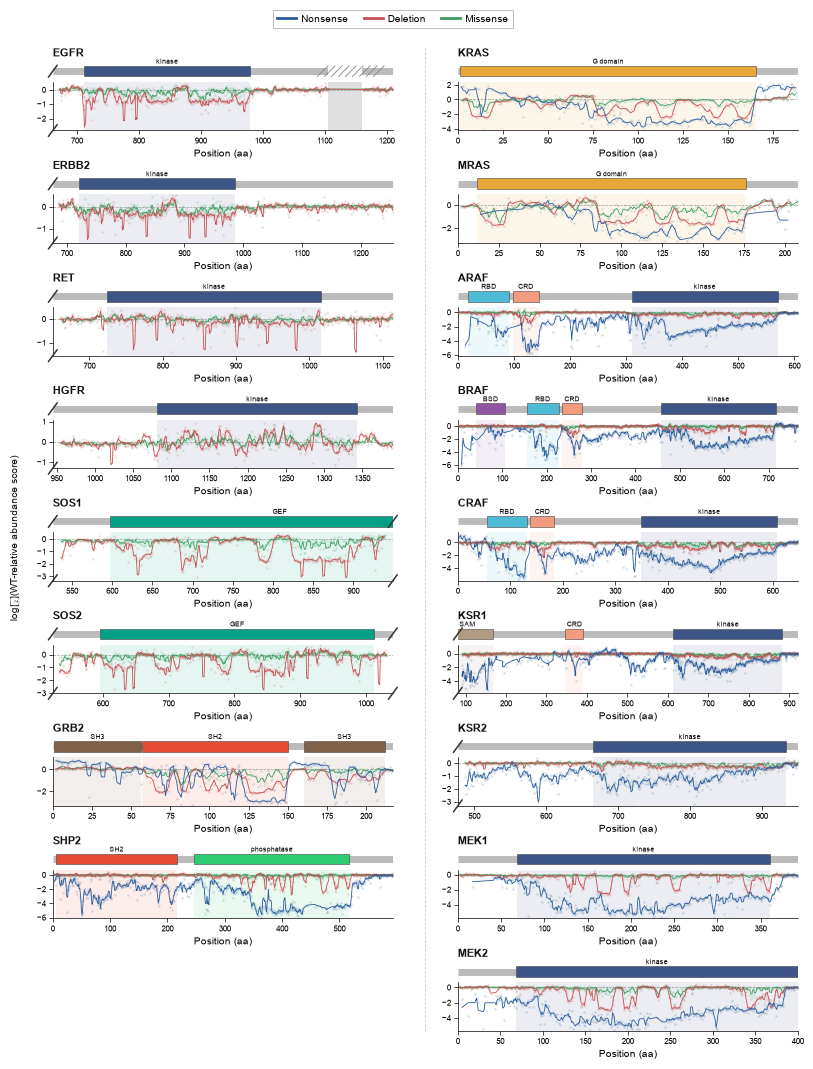

In [5]:
# ── Abundance plot TRUNCATED — domains from Replicate_scores['domain'] column ──
# No manual corrections. Domain bars derived directly from the 'domain' column
# in Replicate_scores rather than from dom_raw / NCBI annotations.

import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from matplotlib.transforms import blended_transform_factory

NEIGHBORS   = 1
WINDOW      = 2 * NEIGHBORS + 1
LINE_WIDTH  = 0.6
X_PAD       = 10

COLOR_NONSENSE = '#2B5C9A'
COLOR_DELETION = '#C44E52'
COLOR_MISSENSE = '#3A9E5F'
DOMAIN_COLORS['BSD']      = '#9055A2'
DOMAIN_COLORS['G domain'] = '#E8A838'

# ── Map Replicate_scores domain column values → DOMAIN_COLORS keys ─────────────
DOMAIN_COL_RENAME = {
    'g_domain':      'G domain',
    'rbd':           'RBD',
    'crd':           'CRD',
    'braf_specific': 'BSD',
    'n_sh3':         'SH3',
    'c_sh3':         'SH3',
    'sh2':           'SH2',
    'sh2_1':         'SH2',
    'sh2_2':         'SH2',
    'gef':           'GEF',
    'sam':           'SAM',
    'kinase':        'kinase',
    'phosphatase':   'phosphatase',
}

# ── Display-name overrides (data lookups still use the original key) ──────────
PROT_DISPLAY_NAME = {
    'met': 'HGFR',
}

LEFT_COL  = ['egfr', 'erbb2', 'ret', 'met',
             'sos1', 'sos2',
             'grb2', 'shp2']
RIGHT_COL = ['kras', 'mras',
             'araf', 'braf', 'craf',
             'ksr1', 'ksr2',
             'mek1', 'mek2']

N_ROWS = max(len(LEFT_COL), len(RIGHT_COL))

FIG_W         = 8.5
FIG_H         = 11.0
LEFT_MARGIN   = 0.85
CENTER_GAP    = 0.65
RIGHT_MARGIN  = 0.20
TOP_MARGIN    = 0.80
BOTTOM_MARGIN = 0.35

COL_W       = (FIG_W - LEFT_MARGIN - CENTER_GAP - RIGHT_MARGIN) / 2
available_H = FIG_H - TOP_MARGIN - BOTTOM_MARGIN
ROW_GAP     = 0.28
PAIR_H      = (available_H - (N_ROWS - 1) * ROW_GAP) / N_ROWS
DOM_H         = 0.32
DOM_SCORE_GAP = 0.04
SCORE_H       = PAIR_H - DOM_H - DOM_SCORE_GAP

HASH_HEIGHT_IN = 0.12
_BAR_CTR_AX    = 0.35 / 1.65
_DOM_HH        = (HASH_HEIGHT_IN / DOM_H)   / 2
_SC_HH         = (HASH_HEIGHT_IN / SCORE_H) / 2
DOM_HASH_Y     = [_BAR_CTR_AX - _DOM_HH, _BAR_CTR_AX + _DOM_HH]
SC_HASH_Y      = [-_SC_HH, _SC_HH]

# ── Score loader — no manual position corrections ─────────────────────────────
def get_abundance_per_position_raw(mut_type, agg='mean'):
    sub = Replicate_scores.copy()
    sub['Position'] = pd.to_numeric(sub['Position'], errors='coerce')
    sub = sub[
        (sub['Mutation Type'] == mut_type) &
        (sub['assay']         == 'abundance') &
        (sub['assay_treatment'].isin(['DMSO', 'No_treatment'])) &
        sub['Position'].notna()
    ].copy()
    sub['Position'] = sub['Position'].astype(int)
    # NOTE: ksr1_cterm +480 shift removed
    grp = sub.groupby(['protein', 'Position'])['average score']
    return (grp.median() if agg == 'median' else grp.mean()).reset_index()

ns_abu_raw  = get_abundance_per_position_raw('nonsense', 'mean')
del_abu_raw = get_abundance_per_position_raw('deletion', 'mean')
mis_abu_raw = get_abundance_per_position_raw('missense', 'mean')

# ── Domain intervals from Replicate_scores['domain'] ─────────────────────────
def get_domains_from_scores(prot, gap_threshold=30):
    """Build (From, To, domain_label) intervals from the 'domain' column."""
    sub = Replicate_scores[
        (Replicate_scores['protein'] == prot) &
        (Replicate_scores['domain'].notna()) &
        (Replicate_scores['domain'] != 'none')
    ].copy()
    sub['Position'] = pd.to_numeric(sub['Position'], errors='coerce')
    sub = sub.dropna(subset=['Position'])
    sub['Position'] = sub['Position'].astype(int)

    if len(sub) == 0:
        return pd.DataFrame(columns=['From', 'To', 'domain_label'])

    pos_dom = (
        sub.groupby('Position')['domain']
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={'domain': 'domain_label'})
        .sort_values('Position')
    )
    pos_dom['domain_label'] = pos_dom['domain_label'].map(
        lambda x: DOMAIN_COL_RENAME.get(x, x)
    )

    rows = []
    pos_arr = pos_dom['Position'].values
    dom_arr = pos_dom['domain_label'].values
    start, current_dom, prev_pos = int(pos_arr[0]), dom_arr[0], int(pos_arr[0])

    for i in range(1, len(pos_arr)):
        pos, dom = int(pos_arr[i]), dom_arr[i]
        if dom != current_dom or pos - prev_pos > gap_threshold:
            rows.append({'From': start, 'To': prev_pos, 'domain_label': current_dom})
            start, current_dom = pos, dom
        prev_pos = pos
    rows.append({'From': start, 'To': prev_pos, 'domain_label': current_dom})

    return pd.DataFrame(rows)

def get_uncovered_regions(pos_list, x_lo, x_hi, gap_threshold=20):
    if not len(pos_list):
        return []
    all_pos = np.array(sorted(set(int(p) for p in pos_list)))
    all_pos = all_pos[(all_pos >= x_lo) & (all_pos <= x_hi)]
    if not len(all_pos):
        return []
    uncovered = []
    for i in range(len(all_pos) - 1):
        if all_pos[i + 1] - all_pos[i] > gap_threshold:
            uncovered.append((int(all_pos[i]), int(all_pos[i + 1])))
    return uncovered

# ── Manually-drawn gap hatch (instead of mpl's hatch=) ────────────────────────
# mpl's hatch= relies on an SVG <pattern> fill; for shapes this narrow the
# pattern's alpha compounds with the patch's own alpha and becomes nearly
# invisible, and some vector viewers don't render pattern fills reliably at
# all. Drawing explicit diagonal lines (clipped to the gap rectangle, at a
# true on-screen 45 degrees) shows up consistently everywhere.
def draw_gap_hatch(ax, x0, x1, y0, y1, facecolor, line_color,
                    face_alpha=0.55, line_alpha=0.9, lw=0.7,
                    spacing_px=7, zorder=1):
    rect = Rectangle((x0, y0), x1 - x0, y1 - y0, facecolor=facecolor,
                      edgecolor='none', alpha=face_alpha, zorder=zorder)
    ax.add_patch(rect)

    ax.figure.canvas.draw()
    inv = ax.transData.inverted()
    ux0, uy0 = inv.transform((0, 0))
    ux1, _   = inv.transform((1, 0))
    _,   uy1 = inv.transform((0, 1))
    dx_per_px = ux1 - ux0
    dy_per_px = uy1 - uy0

    h = y1 - y0
    run_px = h / dy_per_px if dy_per_px != 0 else 0
    dx = run_px * dx_per_px

    clip_box = Rectangle((x0, y0), x1 - x0, y1 - y0, transform=ax.transData)
    step = spacing_px * dx_per_px
    x = x0 - abs(dx)
    while x <= x1 + abs(dx):
        line = Line2D([x, x + dx], [y0, y1], color=line_color, linewidth=lw,
                      alpha=line_alpha, solid_capstyle='butt', zorder=zorder + 0.1)
        line.set_clip_path(clip_box)
        ax.add_line(line)
        x += step

# ── Build figure ──────────────────────────────────────────────────────────────
fig_abu_domcol = plt.figure(figsize=(FIG_W, FIG_H))

col_x_in = [LEFT_MARGIN, LEFT_MARGIN + COL_W + CENTER_GAP]

for ci, col_prots in enumerate([LEFT_COL, RIGHT_COL]):
    x_left_in = col_x_in[ci]

    for ri, prot in enumerate(col_prots):
        prot_len = PROTEIN_LENGTHS.get(prot, 500)

        score_bottom_in = BOTTOM_MARGIN + (N_ROWS - 1 - ri) * (PAIR_H + ROW_GAP)
        dom_bottom_in   = score_bottom_in + SCORE_H + DOM_SCORE_GAP

        ax_dom = fig_abu_domcol.add_axes([x_left_in / FIG_W, dom_bottom_in   / FIG_H,
                                          COL_W     / FIG_W, DOM_H           / FIG_H])
        ax_sc  = fig_abu_domcol.add_axes([x_left_in / FIG_W, score_bottom_in / FIG_H,
                                          COL_W     / FIG_W, SCORE_H         / FIG_H])

        doms  = get_domains_from_scores(prot)
        p_ns  = ns_abu_raw[ns_abu_raw['protein']   == prot].sort_values('Position').copy()
        p_del = del_abu_raw[del_abu_raw['protein'] == prot].sort_values('Position').copy()
        p_mis = mis_abu_raw[mis_abu_raw['protein'] == prot].sort_values('Position').copy()

        all_scored = (list(p_ns['Position']) +
                      list(p_del['Position']) +
                      list(p_mis['Position']))

        if all_scored:
            x_lo = max(0,        min(all_scored) - X_PAD)
            x_hi = min(prot_len, max(all_scored) + X_PAD)
        else:
            x_lo, x_hi = 0, prot_len

        uncovered = get_uncovered_regions(all_scored, x_lo, x_hi)
        dw = (x_hi - x_lo) * 0.013

        # ── Domain panel ─────────────────────────────────────────────────────
        ax_dom.set_xlim(x_lo, x_hi)
        ax_dom.set_ylim(-0.35, 1.30)
        ax_dom.axis('off')

        display_name = PROT_DISPLAY_NAME.get(prot, prot.upper())
        ax_dom.text(x_lo, 1.18, display_name,
                    ha='left', va='top',
                    fontsize=8, fontweight='bold', color='#111111',
                    clip_on=False)

        ax_dom.plot([x_lo, x_hi], [0, 0],
                    color='#BBBBBB', linewidth=5, solid_capstyle='butt', zorder=1)

        for _, drow in doms.iterrows():
            dlbl = drow['domain_label']
            col  = DOMAIN_COLORS.get(dlbl, DOMAIN_COLORS['other'])
            w    = drow['To'] - drow['From']
            ax_dom.barh(0, w, left=drow['From'],
                        color=col, edgecolor='#444444', linewidth=0.4,
                        height=0.55, zorder=2)
            mid = drow['From'] + w / 2
            if mid >= x_lo and mid <= x_hi and w / (x_hi - x_lo) > 0.04:
                ax_dom.text(mid, 0.31, dlbl,
                            ha='center', va='bottom', fontsize=5,
                            color='#111111', clip_on=True)

        for (uc_s, uc_e) in uncovered:
            draw_gap_hatch(ax_dom, uc_s, uc_e, -0.29, 0.29,
                            facecolor='white', line_color='#888888',
                            face_alpha=1.0, line_alpha=0.9, lw=0.7, zorder=4)

        trans_dom = blended_transform_factory(ax_dom.transData, ax_dom.transAxes)
        if x_lo > 0:
            ax_dom.plot([x_lo - dw, x_lo + dw], DOM_HASH_Y,
                        transform=trans_dom, color='#333333', lw=1.1,
                        clip_on=False, zorder=11, solid_capstyle='round')
        if x_hi < prot_len:
            ax_dom.plot([x_hi - dw, x_hi + dw], DOM_HASH_Y,
                        transform=trans_dom, color='#333333', lw=1.1,
                        clip_on=False, zorder=11, solid_capstyle='round')

        # ── Score panel ───────────────────────────────────────────────────────
        for _, drow in doms.iterrows():
            col_d = DOMAIN_COLORS.get(drow['domain_label'], DOMAIN_COLORS['other'])
            ax_sc.axvspan(drow['From'], drow['To'],
                          alpha=0.10, color=col_d, zorder=0, linewidth=0)

        ax_sc.axhline(0.0, color='#888888', linewidth=0.5, linestyle='--',
                      alpha=0.8, zorder=1)

        def log2_scores(pdata):
            if not len(pdata):
                return pdata.copy()
            out = pdata.copy()
            out['average score'] = np.log2(out['average score'].clip(lower=1e-6))
            return out

        p_ns_l  = log2_scores(p_ns)
        p_del_l = log2_scores(p_del)
        p_mis_l = log2_scores(p_mis)

        def smooth(pdata):
            if not len(pdata):
                return pd.Series(dtype=float)
            return pdata['average score'].rolling(window=WINDOW, center=True,
                                                  min_periods=1).mean()

        sm_ns  = smooth(p_ns_l)
        sm_del = smooth(p_del_l)
        sm_mis = smooth(p_mis_l)

        smooth_vals = []
        for sv in [sm_ns, sm_del, sm_mis]:
            smooth_vals.extend(sv.dropna().tolist())

        if smooth_vals:
            ylo = min(smooth_vals)
            yhi = max(smooth_vals)
            pad = max((yhi - ylo) * 0.08, 0.05)
            ylim = (ylo - pad, yhi + pad)
        else:
            ylim = (-1, 1)

        # Uncovered/unscored regions: solid grey shading (no hatch) — the
        # diagonal-line hatch here was rendering past the intended box.
        for (uc_s, uc_e) in uncovered:
            ax_sc.axvspan(uc_s, uc_e, facecolor='#CCCCCC', edgecolor='none',
                          alpha=0.6, zorder=0.5)

        def plot_line(pdata, sm, color, zorder):
            if not len(pdata):
                return
            ax_sc.scatter(pdata['Position'], pdata['average score'],
                          color=color, s=3, alpha=0.20, zorder=zorder,
                          linewidths=0, clip_on=True)
            ax_sc.plot(pdata['Position'], sm,
                       color=color, linewidth=LINE_WIDTH, zorder=zorder + 1)

        plot_line(p_mis_l, sm_mis, COLOR_MISSENSE, zorder=2)
        plot_line(p_del_l, sm_del, COLOR_DELETION,  zorder=4)
        plot_line(p_ns_l,  sm_ns,  COLOR_NONSENSE,  zorder=6)

        ax_sc.set_xlim(x_lo, x_hi)
        ax_sc.set_ylim(*ylim)
        ax_sc.yaxis.set_major_locator(MaxNLocator(nbins=4, steps=[1, 2, 5, 10]))

        ax_sc.tick_params(axis='y', labelsize=6, length=3, width=0.5,
                          pad=2, labelleft=True)
        ax_sc.tick_params(axis='x', labelsize=6, length=3, width=0.5, pad=2)
        ax_sc.set_xlabel('Position (aa)', fontsize=7, labelpad=3)
        ax_sc.set_ylabel('')

        sns.despine(ax=ax_sc)
        for sp in ax_sc.spines.values():
            sp.set_linewidth(0.5)

        trans_sc = blended_transform_factory(ax_sc.transData, ax_sc.transAxes)
        if x_lo > 0:
            ax_sc.plot([x_lo - dw, x_lo + dw], SC_HASH_Y,
                       transform=trans_sc, color='#333333', lw=1.1,
                       clip_on=False, zorder=11, solid_capstyle='round')
        if x_hi < prot_len:
            ax_sc.plot([x_hi - dw, x_hi + dw], SC_HASH_Y,
                       transform=trans_sc, color='#333333', lw=1.1,
                       clip_on=False, zorder=11, solid_capstyle='round')

# ── Shared y-axis label ───────────────────────────────────────────────────────
y_centre = (BOTTOM_MARGIN + available_H / 2) / FIG_H
fig_abu_domcol.text(
    0.055, y_centre,
    'log₂(WT-relative abundance score)',
    va='center', ha='center', rotation=90,
    fontsize=7, color='#111111'
)

# ── Column separator ──────────────────────────────────────────────────────────
sep_x = (LEFT_MARGIN + COL_W + CENTER_GAP / 2) / FIG_W
fig_abu_domcol.add_artist(
    plt.Line2D([sep_x, sep_x],
               [BOTTOM_MARGIN / FIG_H, (BOTTOM_MARGIN + available_H) / FIG_H],
               transform=fig_abu_domcol.transFigure,
               color='#CCCCCC', linewidth=0.6, linestyle='--')
)

# ── Legend ────────────────────────────────────────────────────────────────────
mut_handles = [
    Line2D([0],[0], color=COLOR_NONSENSE, linewidth=2.0, label='Nonsense'),
    Line2D([0],[0], color=COLOR_DELETION,  linewidth=2.0, label='Deletion'),
    Line2D([0],[0], color=COLOR_MISSENSE,  linewidth=2.0, label='Missense'),
]
leg = fig_abu_domcol.legend(
    handles=mut_handles, fontsize=7.5, loc='upper center', ncol=3,
    frameon=True, framealpha=0.9, edgecolor='#AAAAAA', fancybox=False,
    bbox_to_anchor=(0.5, 0.965),
    handlelength=1.8, handleheight=1.0, handletextpad=0.5, columnspacing=1.5,
)
leg.get_frame().set_linewidth(0.6)

plt.savefig(path + 'ED 4.svg', bbox_inches='tight', transparent=True)

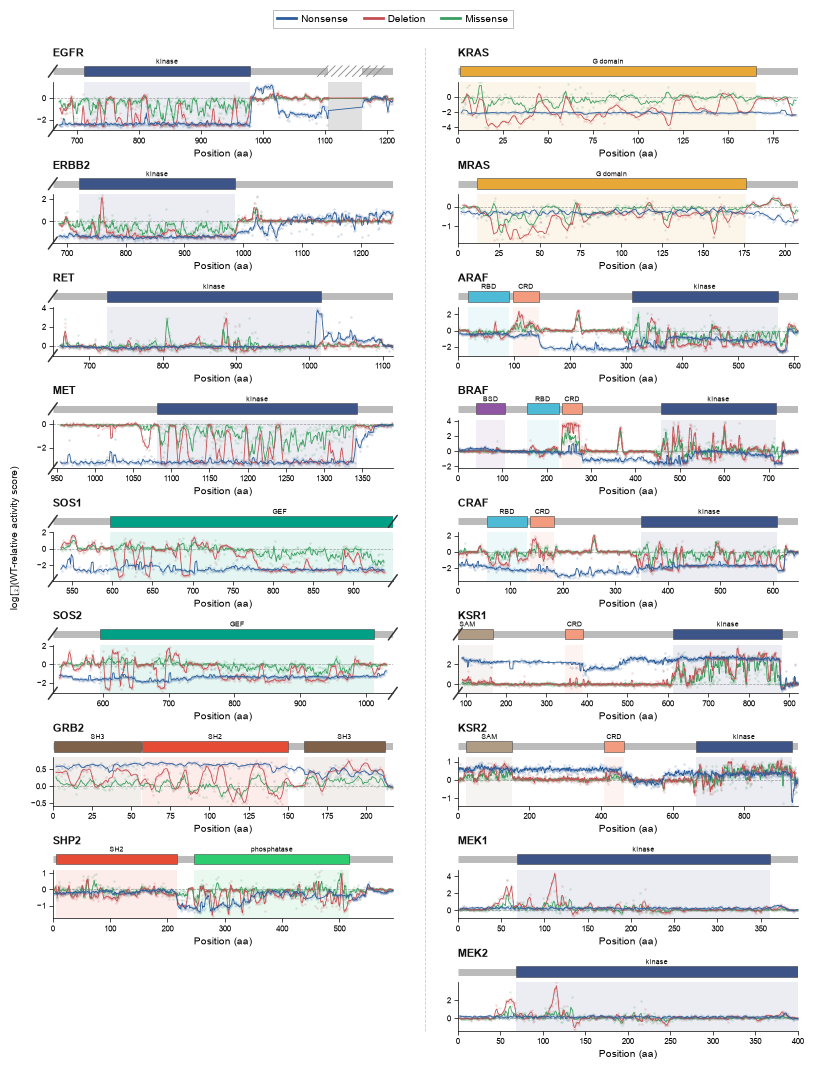

In [6]:
# ── Activity plot TRUNCATED — domains from Replicate_scores['domain'] column ───
# No manual corrections. Domain bars derived directly from the 'domain' column
# in Replicate_scores rather than from dom_raw / NCBI annotations.

import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from matplotlib.transforms import blended_transform_factory

NEIGHBORS   = 1
WINDOW      = 2 * NEIGHBORS + 1
LINE_WIDTH  = 0.6
X_PAD       = 10

COLOR_NONSENSE = '#2B5C9A'
COLOR_DELETION = '#C44E52'
COLOR_MISSENSE = '#3A9E5F'
DOMAIN_COLORS['BSD']      = '#9055A2'
DOMAIN_COLORS['G domain'] = '#E8A838'

# ── Map Replicate_scores domain column values → DOMAIN_COLORS keys ─────────────
DOMAIN_COL_RENAME = {
    'g_domain':      'G domain',
    'rbd':           'RBD',
    'crd':           'CRD',
    'braf_specific': 'BSD',
    'n_sh3':         'SH3',
    'c_sh3':         'SH3',
    'sh2':           'SH2',
    'sh2_1':         'SH2',
    'sh2_2':         'SH2',
    'gef':           'GEF',
    'sam':           'SAM',
    'kinase':        'kinase',
    'phosphatase':   'phosphatase',
}

LEFT_COL  = ['egfr', 'erbb2', 'ret', 'met',
             'sos1', 'sos2',
             'grb2', 'shp2']
RIGHT_COL = ['kras', 'mras',
             'araf', 'braf', 'craf',
             'ksr1', 'ksr2',
             'mek1', 'mek2']

N_ROWS = max(len(LEFT_COL), len(RIGHT_COL))

FIG_W         = 8.5
FIG_H         = 11.0
LEFT_MARGIN   = 0.85
CENTER_GAP    = 0.65
RIGHT_MARGIN  = 0.20
TOP_MARGIN    = 0.80
BOTTOM_MARGIN = 0.35

COL_W       = (FIG_W - LEFT_MARGIN - CENTER_GAP - RIGHT_MARGIN) / 2
available_H = FIG_H - TOP_MARGIN - BOTTOM_MARGIN
ROW_GAP     = 0.28
PAIR_H      = (available_H - (N_ROWS - 1) * ROW_GAP) / N_ROWS
DOM_H         = 0.32
DOM_SCORE_GAP = 0.04
SCORE_H       = PAIR_H - DOM_H - DOM_SCORE_GAP

HASH_HEIGHT_IN = 0.12
_BAR_CTR_AX    = 0.35 / 1.65
_DOM_HH        = (HASH_HEIGHT_IN / DOM_H)   / 2
_SC_HH         = (HASH_HEIGHT_IN / SCORE_H) / 2
DOM_HASH_Y     = [_BAR_CTR_AX - _DOM_HH, _BAR_CTR_AX + _DOM_HH]
SC_HASH_Y      = [-_SC_HH, _SC_HH]

# ── Score loader — no manual position corrections ─────────────────────────────
def get_activity_per_position_raw(mut_type, agg='mean'):
    sub = Replicate_scores.copy()
    sub['Position'] = pd.to_numeric(sub['Position'], errors='coerce')
    sub = sub[
        (sub['Mutation Type'] == mut_type) &
        (sub['assay']         == 'activity') &
        (sub['assay_treatment'].isin(['DMSO', 'No_treatment'])) &
        sub['Position'].notna()
    ].copy()
    sub['Position'] = sub['Position'].astype(int)
    # NOTE: ksr1_cterm +480 and sos2 +534 shifts removed
    grp = sub.groupby(['protein', 'Position'])['average score']
    return (grp.median() if agg == 'median' else grp.mean()).reset_index()

ns_act_raw  = get_activity_per_position_raw('nonsense', 'mean')
del_act_raw = get_activity_per_position_raw('deletion', 'mean')
mis_act_raw = get_activity_per_position_raw('missense', 'mean')

# ── Domain intervals from Replicate_scores['domain'] ─────────────────────────
def get_domains_from_scores(prot, gap_threshold=30):
    """Build (From, To, domain_label) intervals from the 'domain' column."""
    sub = Replicate_scores[
        (Replicate_scores['protein'] == prot) &
        (Replicate_scores['domain'].notna()) &
        (Replicate_scores['domain'] != 'none')
    ].copy()
    sub['Position'] = pd.to_numeric(sub['Position'], errors='coerce')
    sub = sub.dropna(subset=['Position'])
    sub['Position'] = sub['Position'].astype(int)

    if len(sub) == 0:
        return pd.DataFrame(columns=['From', 'To', 'domain_label'])

    pos_dom = (
        sub.groupby('Position')['domain']
        .agg(lambda x: x.mode()[0])
        .reset_index()
        .rename(columns={'domain': 'domain_label'})
        .sort_values('Position')
    )
    pos_dom['domain_label'] = pos_dom['domain_label'].map(
        lambda x: DOMAIN_COL_RENAME.get(x, x)
    )

    rows = []
    pos_arr = pos_dom['Position'].values
    dom_arr = pos_dom['domain_label'].values
    start, current_dom, prev_pos = int(pos_arr[0]), dom_arr[0], int(pos_arr[0])

    for i in range(1, len(pos_arr)):
        pos, dom = int(pos_arr[i]), dom_arr[i]
        if dom != current_dom or pos - prev_pos > gap_threshold:
            rows.append({'From': start, 'To': prev_pos, 'domain_label': current_dom})
            start, current_dom = pos, dom
        prev_pos = pos
    rows.append({'From': start, 'To': prev_pos, 'domain_label': current_dom})

    return pd.DataFrame(rows)

def get_uncovered_regions(pos_list, x_lo, x_hi, gap_threshold=20):
    if not len(pos_list):
        return []
    all_pos = np.array(sorted(set(int(p) for p in pos_list)))
    all_pos = all_pos[(all_pos >= x_lo) & (all_pos <= x_hi)]
    if not len(all_pos):
        return []
    uncovered = []
    for i in range(len(all_pos) - 1):
        if all_pos[i + 1] - all_pos[i] > gap_threshold:
            uncovered.append((int(all_pos[i]), int(all_pos[i + 1])))
    return uncovered

# ── Manually-drawn gap hatch (instead of mpl's hatch=) ────────────────────────
# mpl's hatch= relies on an SVG <pattern> fill; for shapes this narrow the
# pattern's alpha compounds with the patch's own alpha and becomes nearly
# invisible, and some vector viewers don't render pattern fills reliably at
# all. Drawing explicit diagonal lines (clipped to the gap rectangle, at a
# true on-screen 45 degrees) shows up consistently everywhere.
def draw_gap_hatch(ax, x0, x1, y0, y1, facecolor, line_color,
                    face_alpha=0.55, line_alpha=0.9, lw=0.7,
                    spacing_px=7, zorder=1):
    rect = Rectangle((x0, y0), x1 - x0, y1 - y0, facecolor=facecolor,
                      edgecolor='none', alpha=face_alpha, zorder=zorder)
    ax.add_patch(rect)

    ax.figure.canvas.draw()
    inv = ax.transData.inverted()
    ux0, uy0 = inv.transform((0, 0))
    ux1, _   = inv.transform((1, 0))
    _,   uy1 = inv.transform((0, 1))
    dx_per_px = ux1 - ux0
    dy_per_px = uy1 - uy0

    h = y1 - y0
    run_px = h / dy_per_px if dy_per_px != 0 else 0
    dx = run_px * dx_per_px

    clip_box = Rectangle((x0, y0), x1 - x0, y1 - y0, transform=ax.transData)
    step = spacing_px * dx_per_px
    x = x0 - abs(dx)
    while x <= x1 + abs(dx):
        line = Line2D([x, x + dx], [y0, y1], color=line_color, linewidth=lw,
                      alpha=line_alpha, solid_capstyle='butt', zorder=zorder + 0.1)
        line.set_clip_path(clip_box)
        ax.add_line(line)
        x += step

# ── Build figure ──────────────────────────────────────────────────────────────
fig_act_domcol = plt.figure(figsize=(FIG_W, FIG_H))

col_x_in = [LEFT_MARGIN, LEFT_MARGIN + COL_W + CENTER_GAP]

for ci, col_prots in enumerate([LEFT_COL, RIGHT_COL]):
    x_left_in = col_x_in[ci]

    for ri, prot in enumerate(col_prots):
        prot_len = PROTEIN_LENGTHS.get(prot, 500)

        score_bottom_in = BOTTOM_MARGIN + (N_ROWS - 1 - ri) * (PAIR_H + ROW_GAP)
        dom_bottom_in   = score_bottom_in + SCORE_H + DOM_SCORE_GAP

        ax_dom = fig_act_domcol.add_axes([x_left_in / FIG_W, dom_bottom_in   / FIG_H,
                                          COL_W     / FIG_W, DOM_H           / FIG_H])
        ax_sc  = fig_act_domcol.add_axes([x_left_in / FIG_W, score_bottom_in / FIG_H,
                                          COL_W     / FIG_W, SCORE_H         / FIG_H])

        doms  = get_domains_from_scores(prot)
        p_ns  = ns_act_raw[ns_act_raw['protein']   == prot].sort_values('Position').copy()
        p_del = del_act_raw[del_act_raw['protein'] == prot].sort_values('Position').copy()
        p_mis = mis_act_raw[mis_act_raw['protein'] == prot].sort_values('Position').copy()

        all_scored = (list(p_ns['Position']) +
                      list(p_del['Position']) +
                      list(p_mis['Position']))

        if all_scored:
            x_lo = max(0,        min(all_scored) - X_PAD)
            x_hi = min(prot_len, max(all_scored) + X_PAD)
        else:
            x_lo, x_hi = 0, prot_len

        uncovered = get_uncovered_regions(all_scored, x_lo, x_hi)
        dw = (x_hi - x_lo) * 0.013

        # ── Domain panel ─────────────────────────────────────────────────────
        ax_dom.set_xlim(x_lo, x_hi)
        ax_dom.set_ylim(-0.35, 1.30)
        ax_dom.axis('off')

        ax_dom.text(x_lo, 1.18, prot.upper(),
                    ha='left', va='top',
                    fontsize=8, fontweight='bold', color='#111111',
                    clip_on=False)

        ax_dom.plot([x_lo, x_hi], [0, 0],
                    color='#BBBBBB', linewidth=5, solid_capstyle='butt', zorder=1)

        for _, drow in doms.iterrows():
            dlbl = drow['domain_label']
            col  = DOMAIN_COLORS.get(dlbl, DOMAIN_COLORS['other'])
            w    = drow['To'] - drow['From']
            ax_dom.barh(0, w, left=drow['From'],
                        color=col, edgecolor='#444444', linewidth=0.4,
                        height=0.55, zorder=2)
            mid = drow['From'] + w / 2
            if mid >= x_lo and mid <= x_hi and w / (x_hi - x_lo) > 0.04:
                ax_dom.text(mid, 0.31, dlbl,
                            ha='center', va='bottom', fontsize=5,
                            color='#111111', clip_on=True)

        for (uc_s, uc_e) in uncovered:
            draw_gap_hatch(ax_dom, uc_s, uc_e, -0.29, 0.29,
                            facecolor='white', line_color='#888888',
                            face_alpha=1.0, line_alpha=0.9, lw=0.7, zorder=4)

        trans_dom = blended_transform_factory(ax_dom.transData, ax_dom.transAxes)
        if x_lo > 0:
            ax_dom.plot([x_lo - dw, x_lo + dw], DOM_HASH_Y,
                        transform=trans_dom, color='#333333', lw=1.1,
                        clip_on=False, zorder=11, solid_capstyle='round')
        if x_hi < prot_len:
            ax_dom.plot([x_hi - dw, x_hi + dw], DOM_HASH_Y,
                        transform=trans_dom, color='#333333', lw=1.1,
                        clip_on=False, zorder=11, solid_capstyle='round')

        # ── Score panel ───────────────────────────────────────────────────────
        for _, drow in doms.iterrows():
            col_d = DOMAIN_COLORS.get(drow['domain_label'], DOMAIN_COLORS['other'])
            ax_sc.axvspan(drow['From'], drow['To'],
                          alpha=0.10, color=col_d, zorder=0, linewidth=0)

        ax_sc.axhline(0.0, color='#888888', linewidth=0.5, linestyle='--',
                      alpha=0.8, zorder=1)

        def log2_scores(pdata):
            if not len(pdata):
                return pdata.copy()
            out = pdata.copy()
            out['average score'] = np.log2(out['average score'].clip(lower=1e-6))
            return out

        p_ns_l  = log2_scores(p_ns)
        p_del_l = log2_scores(p_del)
        p_mis_l = log2_scores(p_mis)

        def smooth(pdata):
            if not len(pdata):
                return pd.Series(dtype=float)
            return pdata['average score'].rolling(window=WINDOW, center=True,
                                                  min_periods=1).mean()

        sm_ns  = smooth(p_ns_l)
        sm_del = smooth(p_del_l)
        sm_mis = smooth(p_mis_l)

        smooth_vals = []
        for sv in [sm_ns, sm_del, sm_mis]:
            smooth_vals.extend(sv.dropna().tolist())

        if smooth_vals:
            ylo = min(smooth_vals)
            yhi = max(smooth_vals)
            pad = max((yhi - ylo) * 0.08, 0.05)
            ylim = (ylo - pad, yhi + pad)
        else:
            ylim = (-3, 3)

        # Uncovered/unscored regions: solid grey shading (no hatch) — the
        # diagonal-line hatch here was rendering past the intended box.
        for (uc_s, uc_e) in uncovered:
            ax_sc.axvspan(uc_s, uc_e, facecolor='#CCCCCC', edgecolor='none',
                          alpha=0.6, zorder=0.5)

        def plot_line(pdata, sm, color, zorder):
            if not len(pdata):
                return
            ax_sc.scatter(pdata['Position'], pdata['average score'],
                          color=color, s=3, alpha=0.20, zorder=zorder,
                          linewidths=0, clip_on=True)
            ax_sc.plot(pdata['Position'], sm,
                       color=color, linewidth=LINE_WIDTH, zorder=zorder + 1)

        plot_line(p_mis_l, sm_mis, COLOR_MISSENSE, zorder=2)
        plot_line(p_del_l, sm_del, COLOR_DELETION,  zorder=4)
        plot_line(p_ns_l,  sm_ns,  COLOR_NONSENSE,  zorder=6)

        ax_sc.set_xlim(x_lo, x_hi)
        ax_sc.set_ylim(*ylim)
        ax_sc.yaxis.set_major_locator(MaxNLocator(nbins=4, steps=[1, 2, 5, 10]))

        ax_sc.tick_params(axis='y', labelsize=6, length=3, width=0.5,
                          pad=2, labelleft=True)
        ax_sc.tick_params(axis='x', labelsize=6, length=3, width=0.5, pad=2)
        ax_sc.set_xlabel('Position (aa)', fontsize=7, labelpad=3)
        ax_sc.set_ylabel('')

        sns.despine(ax=ax_sc)
        for sp in ax_sc.spines.values():
            sp.set_linewidth(0.5)

        trans_sc = blended_transform_factory(ax_sc.transData, ax_sc.transAxes)
        if x_lo > 0:
            ax_sc.plot([x_lo - dw, x_lo + dw], SC_HASH_Y,
                       transform=trans_sc, color='#333333', lw=1.1,
                       clip_on=False, zorder=11, solid_capstyle='round')
        if x_hi < prot_len:
            ax_sc.plot([x_hi - dw, x_hi + dw], SC_HASH_Y,
                       transform=trans_sc, color='#333333', lw=1.1,
                       clip_on=False, zorder=11, solid_capstyle='round')

# ── Shared y-axis label ───────────────────────────────────────────────────────
y_centre = (BOTTOM_MARGIN + available_H / 2) / FIG_H
fig_act_domcol.text(
    0.055, y_centre,
    'log₂(WT-relative activity score)',
    va='center', ha='center', rotation=90,
    fontsize=7, color='#111111'
)

# ── Column separator ──────────────────────────────────────────────────────────
sep_x = (LEFT_MARGIN + COL_W + CENTER_GAP / 2) / FIG_W
fig_act_domcol.add_artist(
    plt.Line2D([sep_x, sep_x],
               [BOTTOM_MARGIN / FIG_H, (BOTTOM_MARGIN + available_H) / FIG_H],
               transform=fig_act_domcol.transFigure,
               color='#CCCCCC', linewidth=0.6, linestyle='--')
)

# ── Legend ────────────────────────────────────────────────────────────────────
mut_handles = [
    Line2D([0],[0], color=COLOR_NONSENSE, linewidth=2.0, label='Nonsense'),
    Line2D([0],[0], color=COLOR_DELETION,  linewidth=2.0, label='Deletion'),
    Line2D([0],[0], color=COLOR_MISSENSE,  linewidth=2.0, label='Missense'),
]
leg = fig_act_domcol.legend(
    handles=mut_handles, fontsize=7.5, loc='upper center', ncol=3,
    frameon=True, framealpha=0.9, edgecolor='#AAAAAA', fancybox=False,
    bbox_to_anchor=(0.5, 0.965),
    handlelength=1.8, handleheight=1.0, handletextpad=0.5, columnspacing=1.5,
)
leg.get_frame().set_linewidth(0.6)

plt.savefig(path + 'ED 5.svg', bbox_inches='tight', transparent=True)


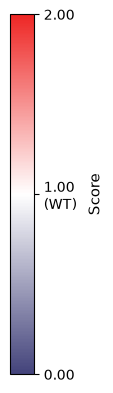

Saved: colorbar.svg


In [5]:
"""
Generate an SVG color bar (legend) matching the blue-white-red coloring
scheme used in the PyMOL script (determine_color function).

Run this in a Jupyter notebook cell, or as a standalone script.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Match these to the values used in your PyMOL script ---
MIN_VALUE = 0
MAX_VALUE = 2
WILD_TYPE = 1

# Colors used in the PyMOL script (as 0-1 fractions, not 0-255)
BLUE  = (0.263, 0.263, 0.482)
WHITE = (1.0, 1.0, 1.0)
RED   = (0.933, 0.153, 0.145)

# --- Build a colormap with a non-uniform white midpoint at WILD_TYPE ---
# This mirrors the piecewise lerp: blue->white over [MIN_VALUE, WILD_TYPE],
# white->red over [WILD_TYPE, MAX_VALUE].
midpoint_frac = (WILD_TYPE - MIN_VALUE) / (MAX_VALUE - MIN_VALUE)

cdict = {
    'red':   [(0.0, BLUE[0], BLUE[0]),
              (midpoint_frac, WHITE[0], WHITE[0]),
              (1.0, RED[0], RED[0])],
    'green': [(0.0, BLUE[1], BLUE[1]),
              (midpoint_frac, WHITE[1], WHITE[1]),
              (1.0, RED[1], RED[1])],
    'blue':  [(0.0, BLUE[2], BLUE[2]),
              (midpoint_frac, WHITE[2], WHITE[2]),
              (1.0, RED[2], RED[2])],
}

cmap = mcolors.LinearSegmentedColormap('pymol_bwr', cdict, N=256)
norm = mcolors.Normalize(vmin=MIN_VALUE, vmax=MAX_VALUE)

# --- Plot the colorbar ---
fig, ax = plt.subplots(figsize=(1.2, 4))  # tall, narrow — vertical bar
fig.subplots_adjust(left=0.4, right=0.6, top=0.95, bottom=0.05)

cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation='vertical'
)

# Tick at wild-type value plus min/max
cb.set_ticks([MIN_VALUE, WILD_TYPE, MAX_VALUE])
cb.set_ticklabels([f"{MIN_VALUE:.2f}", f"{WILD_TYPE:.2f}\n(WT)", f"{MAX_VALUE:.2f}"])
cb.ax.tick_params(labelsize=10)
cb.outline.set_linewidth(0.8)

cb.set_label("Score", fontsize=11, labelpad=8)

# Save as SVG (vector, editable in Illustrator — good for Nature figures)
fig.savefig("colorbar.svg", format="svg", bbox_inches="tight", transparent=True)
plt.show()

print("Saved: colorbar.svg")
